## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_exp = pd.read_excel('env2.xlsx', sheet_name='Sheet1')#sheet_full_environment_experiments
data_sumo_rl = pd.read_excel("SUMO-RL-EXP.xlsx")



In [3]:
data_exp.head(4)

,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Total Time Of Training (M),Reward on Final Test,Waiting Time (s) on Final Test,Speed (m/s) on Final Test,Depart Delay (s) on Final Test,Time Loss (s) on Final Test,Waiting Car on Final Test,Device,Notes,Study Group
0,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),0,NaN,0.599,...,3.852,18.150375,154.57,6.97,8.38,656.51,14,colab,NaN,NaN
1,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),1,NaN,1.123,...,2.701,28.852312,1100.47,6.17,63.56,1362.82,38,colab,NaN,NaN
2,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),2,NaN,4.815,...,2.793,17.185500,514.39,6.91,19.66,999.00,1,colab,NaN,NaN
3,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),3,NaN,6.675,...,3.804,36.497437,1181.04,5.95,55.84,1492.69,17,colab,NaN,NaN


In [4]:
# Run this cell once
data_sumo_rl = data_sumo_rl.drop(['Device', 'Notes', 'Study Group'],axis = 1)
data_exp =  data_exp.drop(['Device', 'Notes', 'Study Group'],axis = 1)

## Helper Functions

In [7]:
def get_grouped_seed(data):
    # If used old version , you should modify it to use 4 seeds which are 0, 1, 2, 3
    group_cols = ['Area', 'Reward', 'Algorithm', 'Traffic Scale']
    if 'Environment Type' in data.columns:
        group_cols.append('Environment Type')
    numeric_cols = data.select_dtypes(include='number').columns
    # remove Seed before averaging
    result = (
        data
        .groupby(group_cols)
        .mean()
        .reset_index()
    )
    return result



In [8]:
#pip install nbformat>=4.2.0
#pip install seaborn

In [9]:
def plot_with_benchmark(
    data_exp, 
    data_bench_groubed, 
    area, 
    column_y, 
    reward='Proposed', 
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Filter benchmark data
    data_bench_groubed = data_bench_groubed[data_bench_groubed['Area'] == area]
    column_x = 'Traffic Scale'

    # Filter experimental data for the selected reward
    data_exp_filtered = data_exp[data_exp['Reward'] == reward]

    # --- Create FacetGrid ---
    g = sns.FacetGrid(
        data_exp_filtered,
        col="Algorithm",
        row="Environment Type",
       # hue="Reward",
        margin_titles=True,
        height=4,
        aspect=1.2
    )

    # --- Boxplot per x-axis point ---
    def boxplot_per_x(data, **kwargs):
        ax = plt.gca()
        grouped = data.groupby(column_x)[column_y]

        x_labels = sorted(grouped.groups.keys())
        box_data = [grouped.get_group(x).values for x in x_labels]
        x_positions = range(len(x_labels))

        ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.25,
            showfliers=False,
            patch_artist=True
        )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel(column_y)

    g.map_dataframe(boxplot_per_x)

    
    # --- Add benchmark points for the specified reward ---
    for ax, (env, algo) in zip(
        g.axes.flat,
        [(e, a) for e in data_exp_filtered["Environment Type"].unique()
               for a in data_exp_filtered["Algorithm"].unique()]
    ):
        subset_bench = data_bench_groubed[
            (data_bench_groubed['Algorithm'] == algo) &
            (data_bench_groubed['Reward'] == reward)
        ]

        if not subset_bench.empty:
            ax.scatter(
                subset_bench[column_x],
                subset_bench[column_y],
                color='purple',
                marker='$-$',
                s=3500,
                linewidth=1.5,
                label=f"Benchmark {reward}"
            )

    # --- Formatting ---
    g.add_legend()
    g.figure.suptitle(
        f"Performance Comparison (Using Reward : {reward})\n{column_y} on area {area}",
        fontsize=16
    )
    g.figure.subplots_adjust(top=0.9)
    plt.show()


## Plots 

In [11]:
data_bench_grouped = get_grouped_seed(data_sumo_rl)


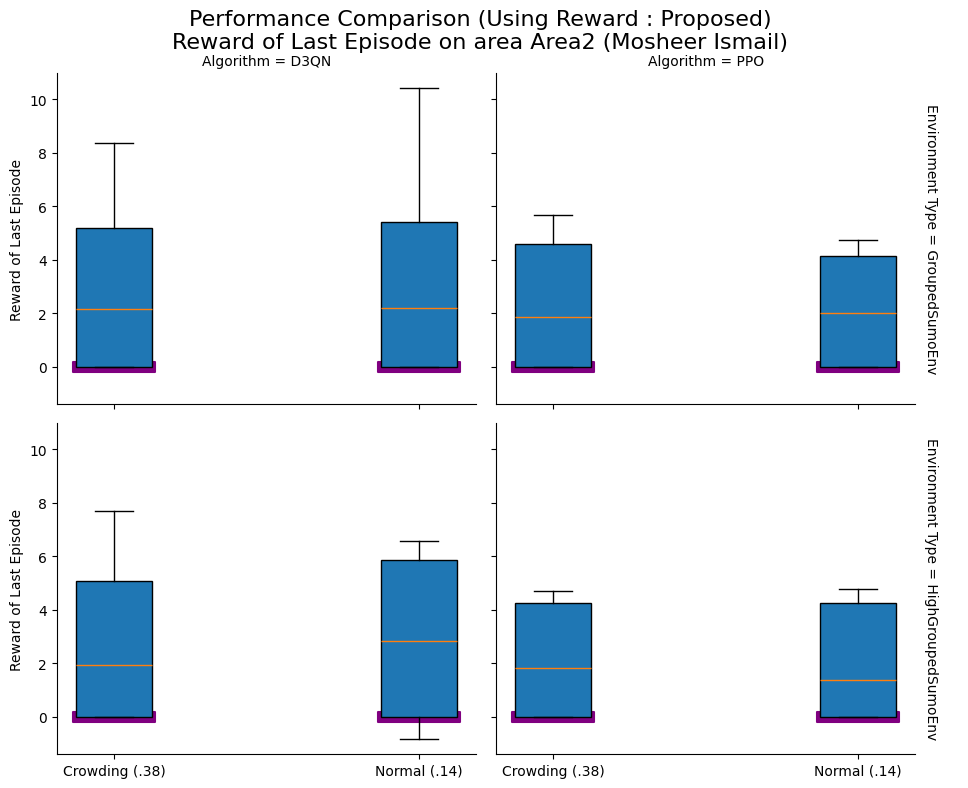

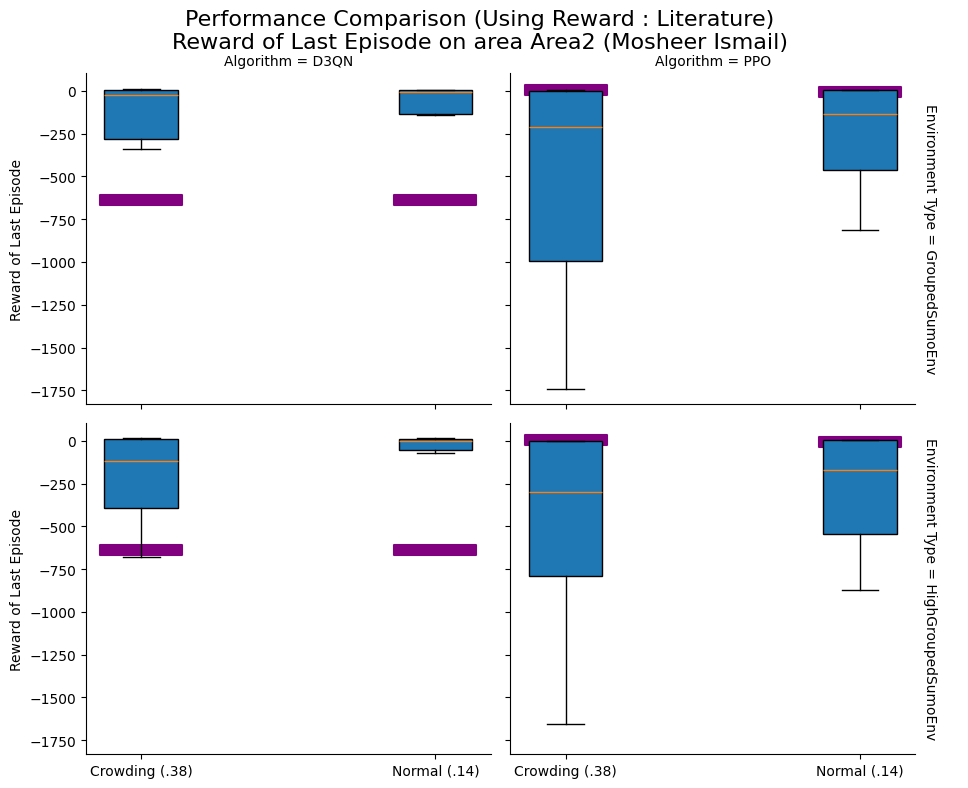

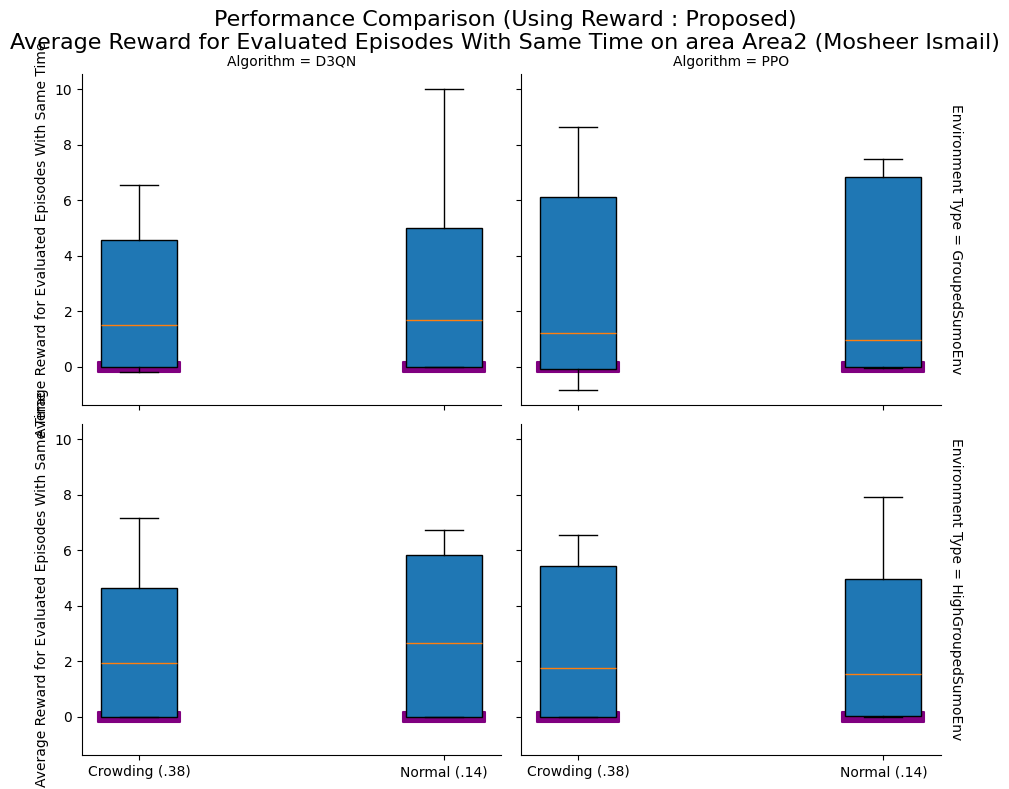

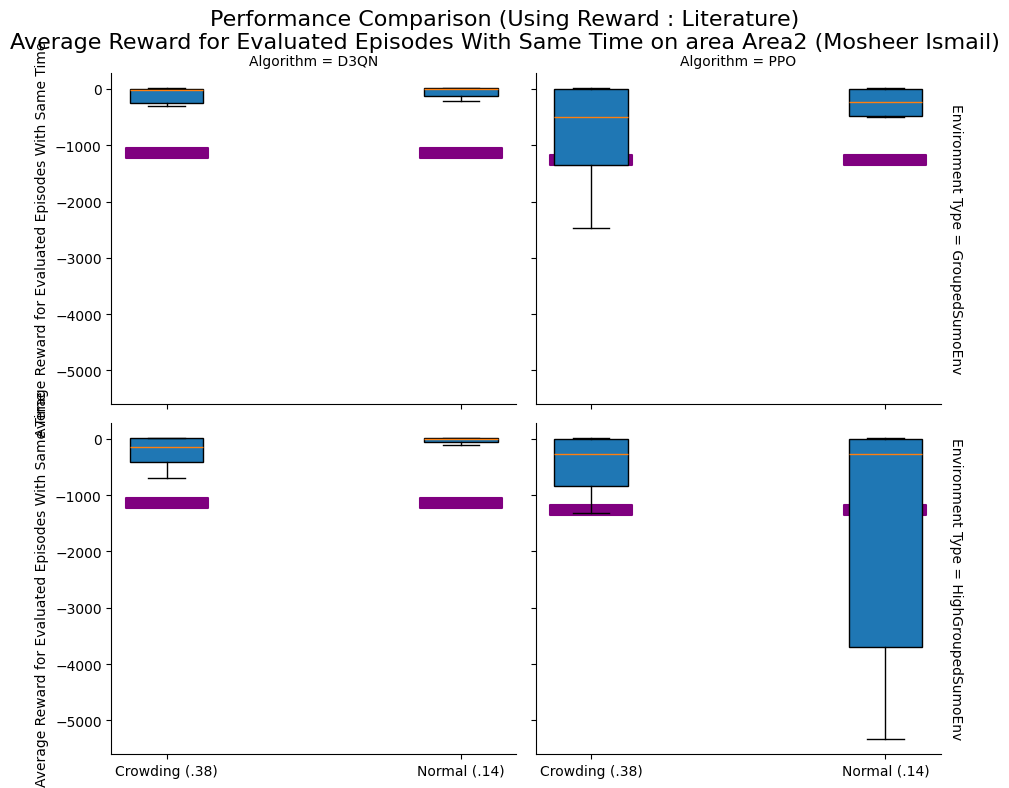

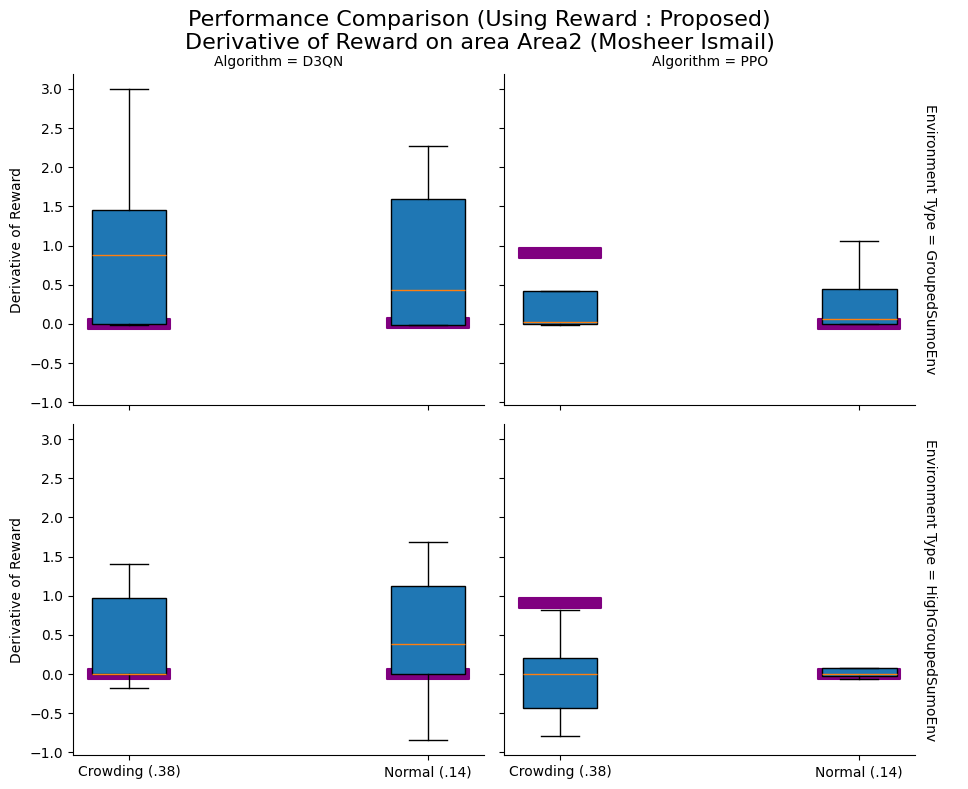

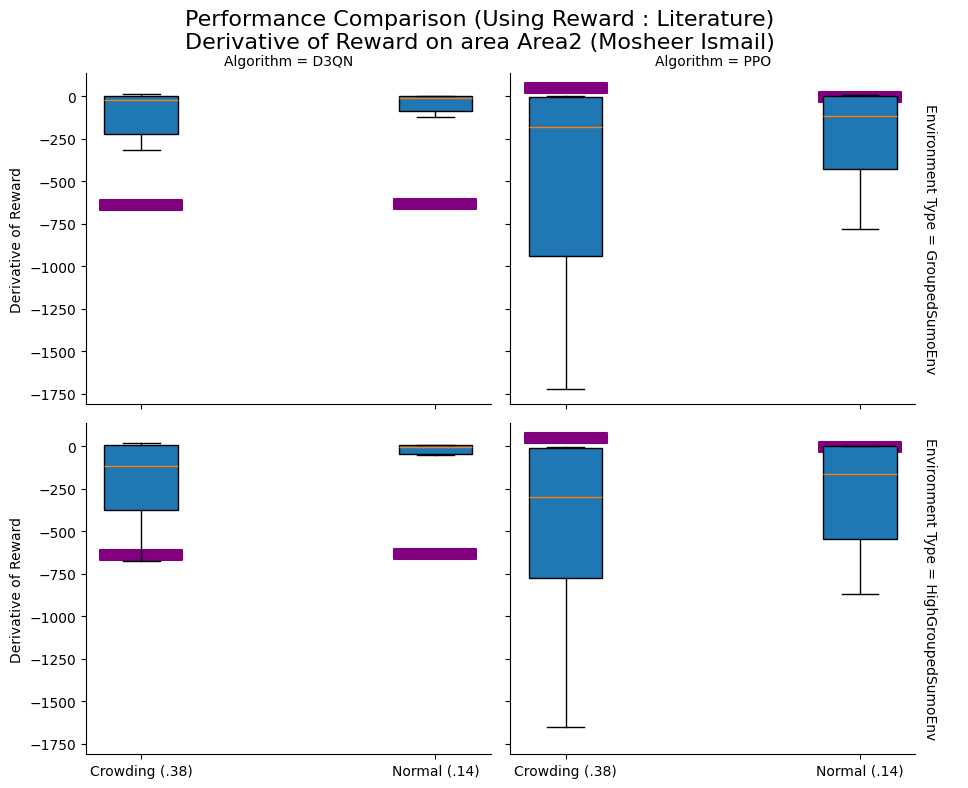

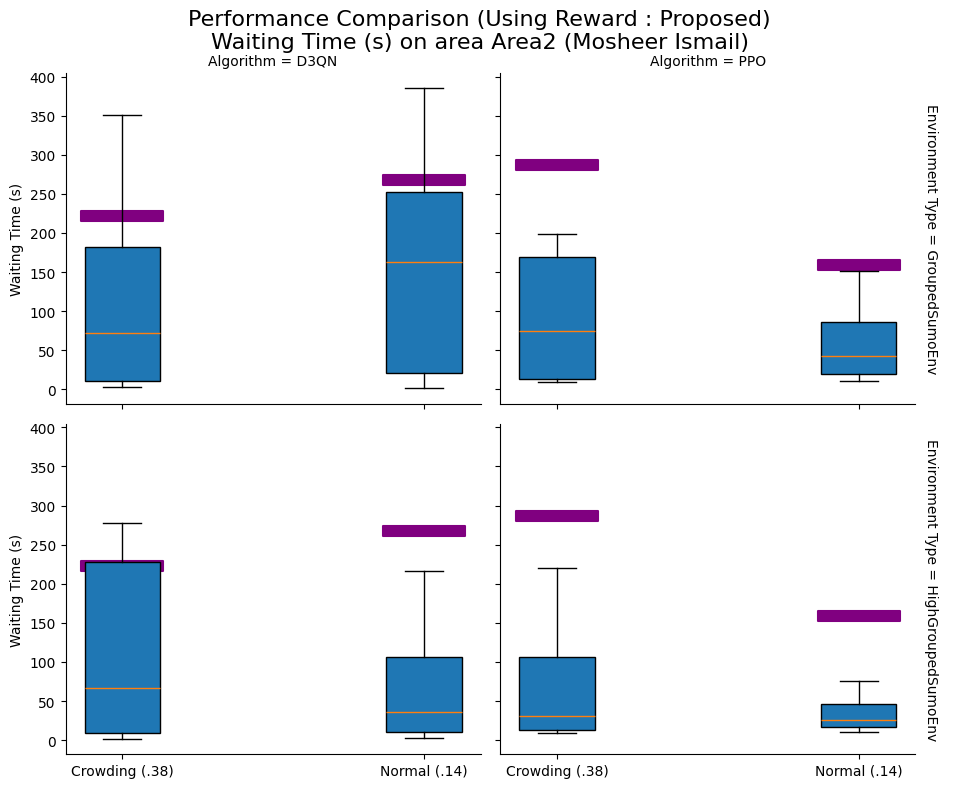

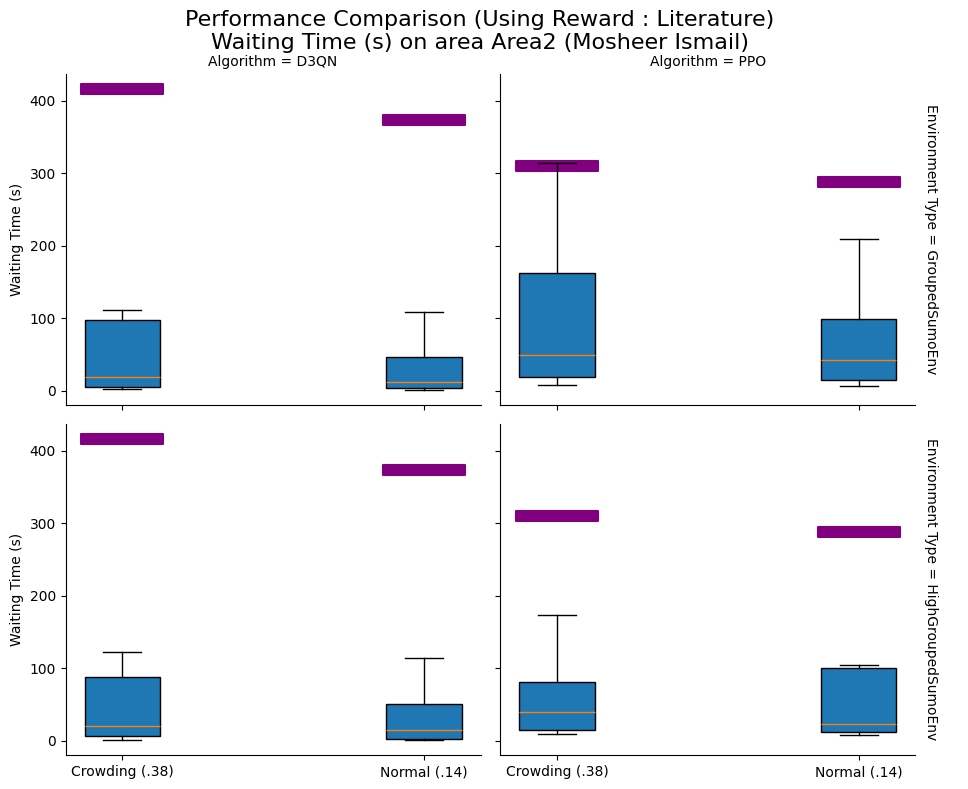

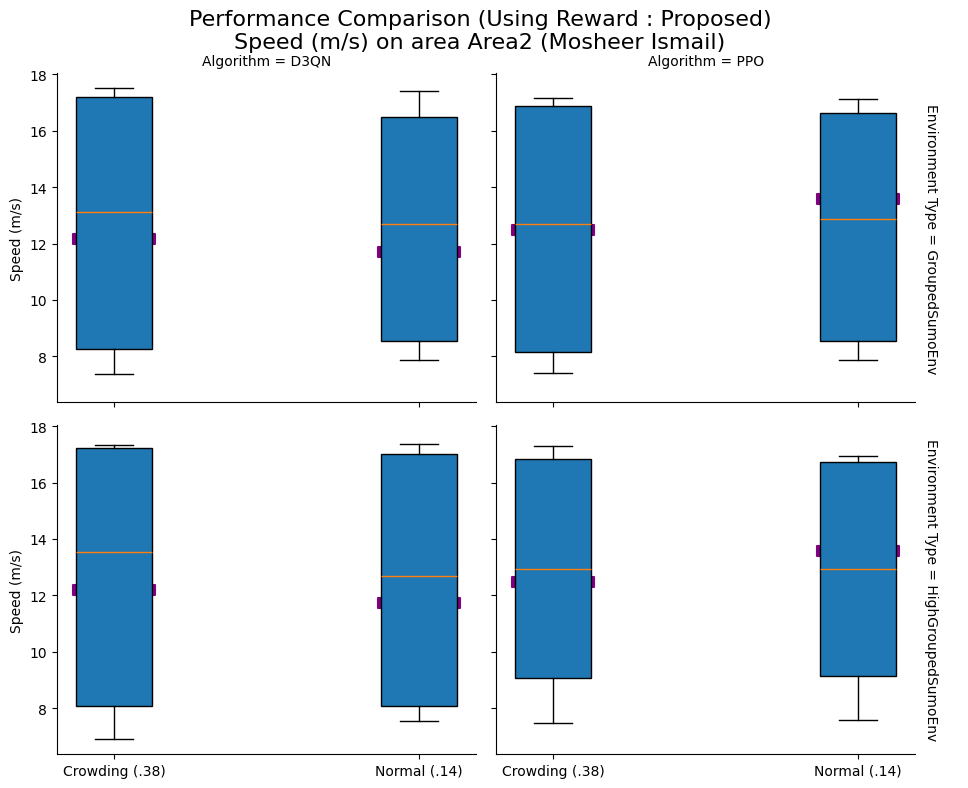

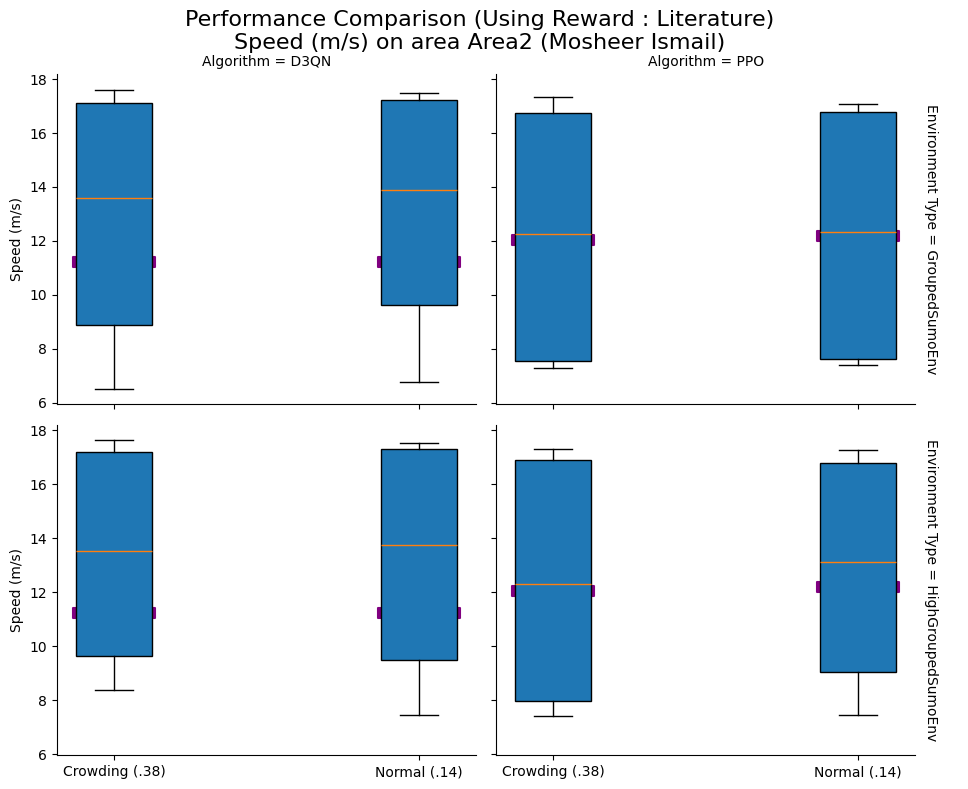

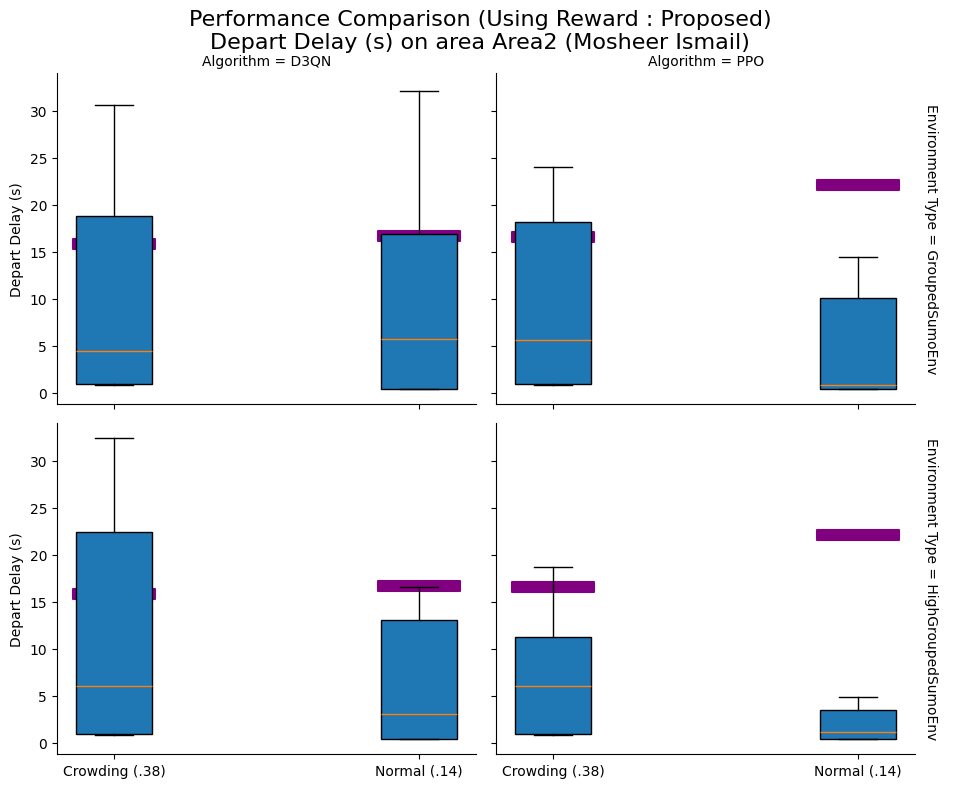

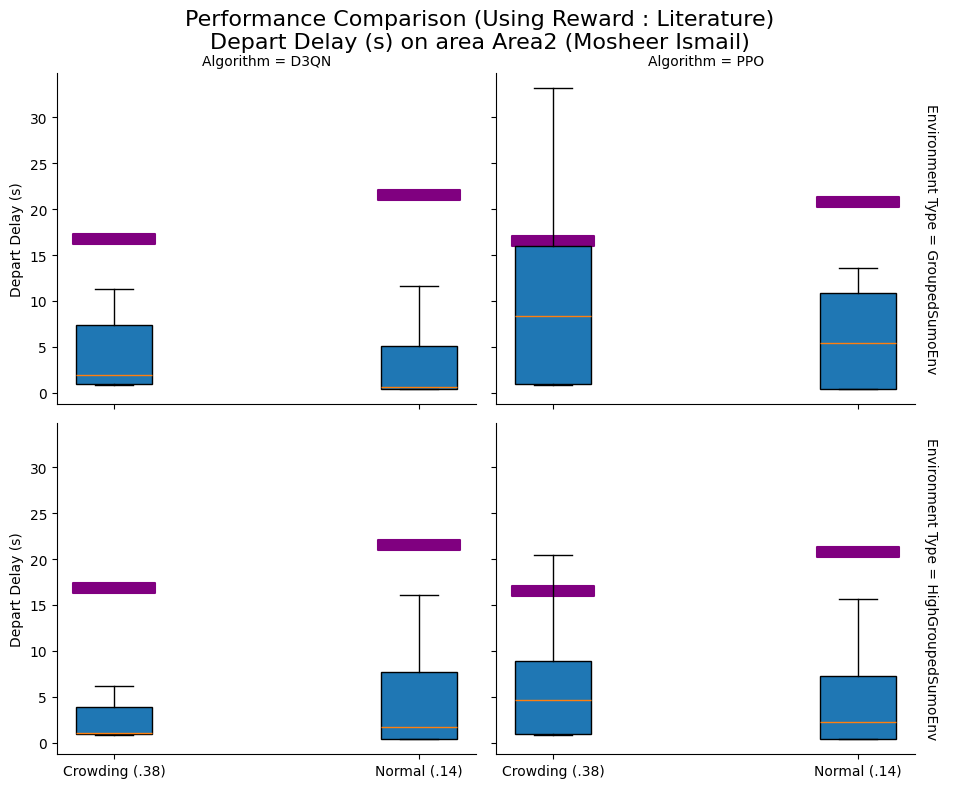

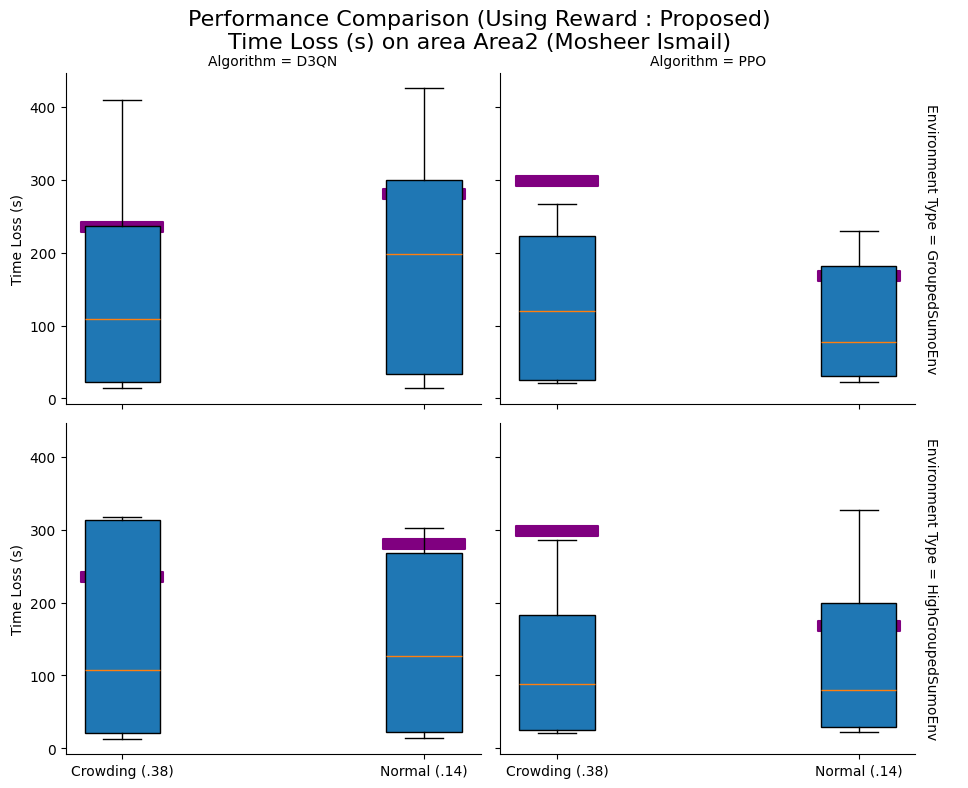

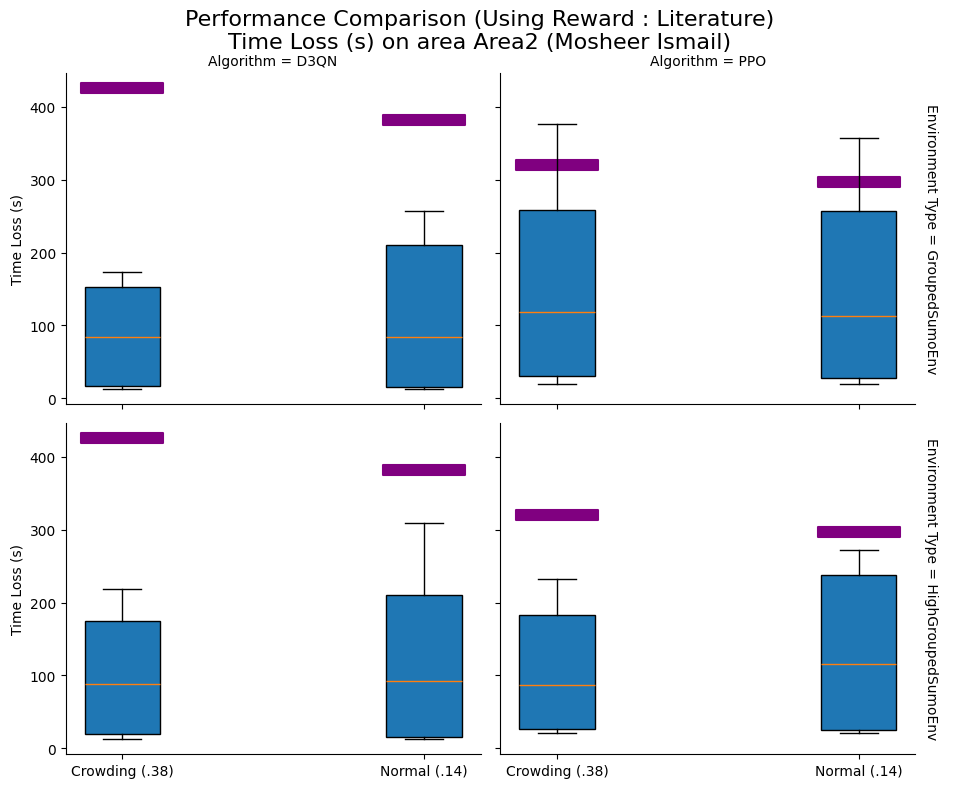

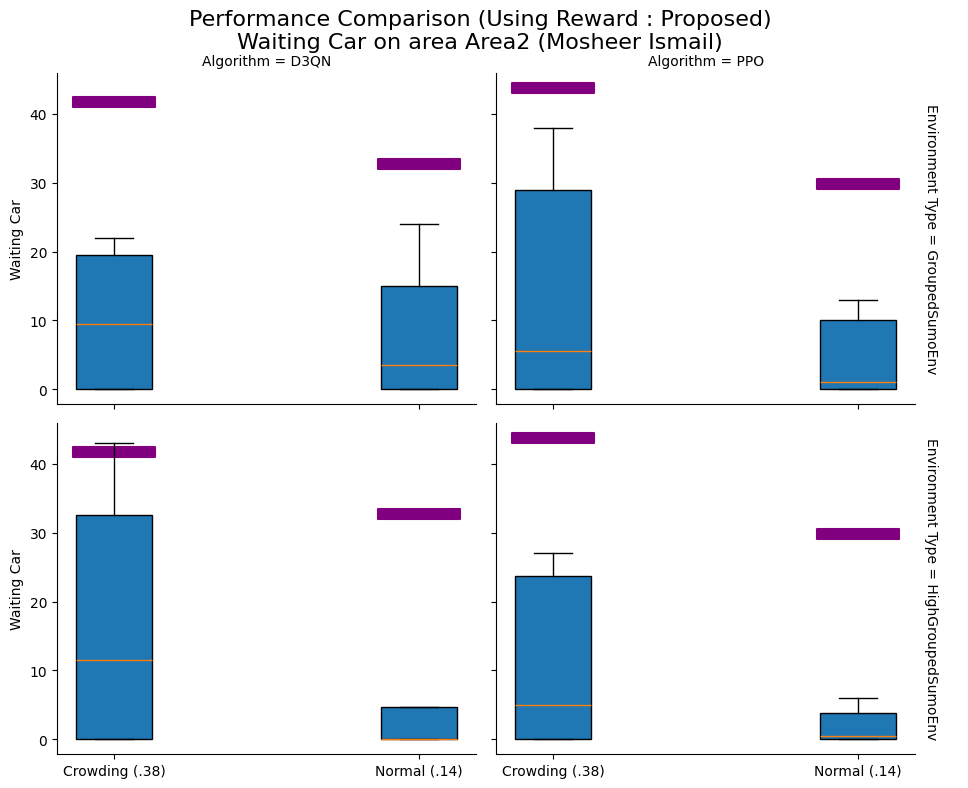

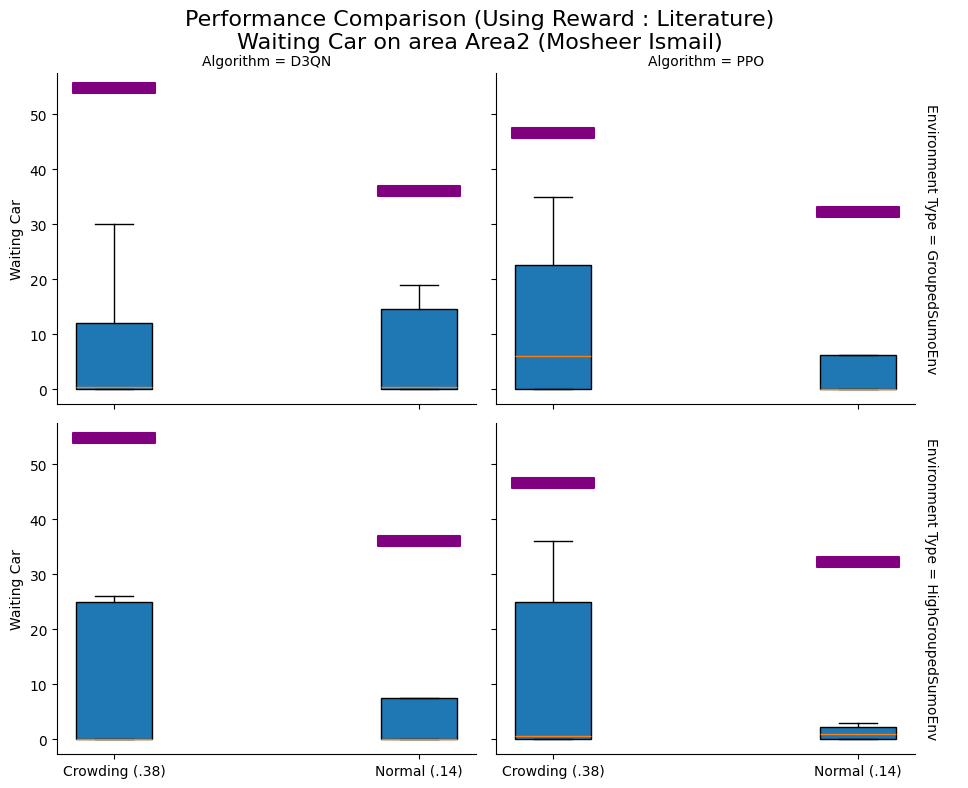

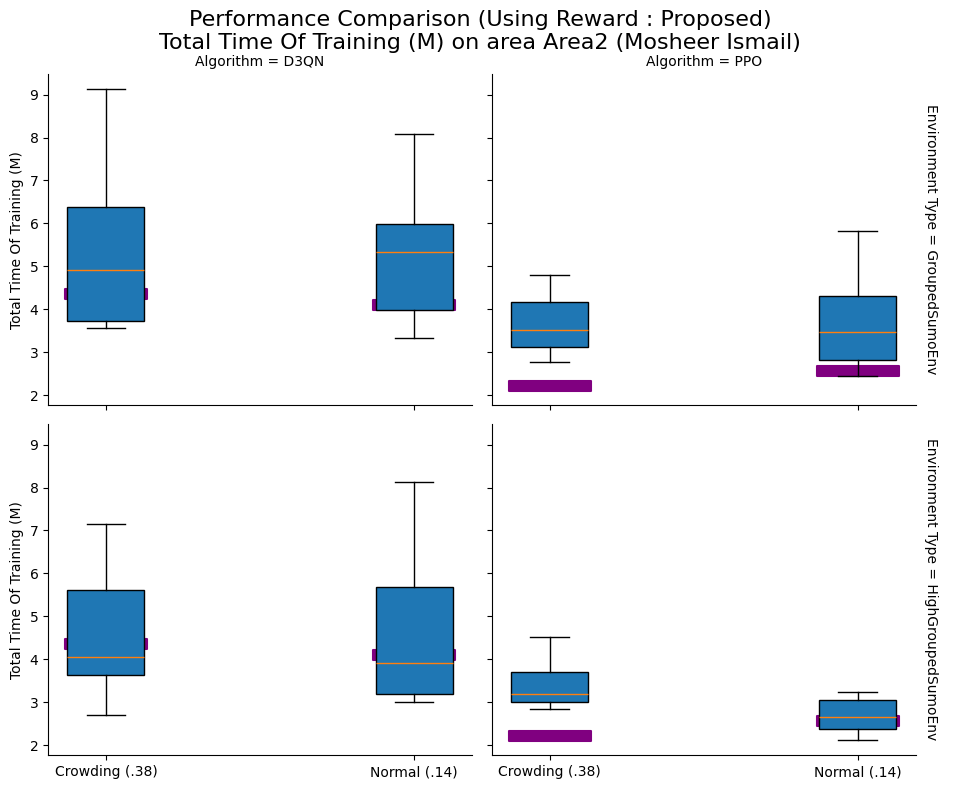

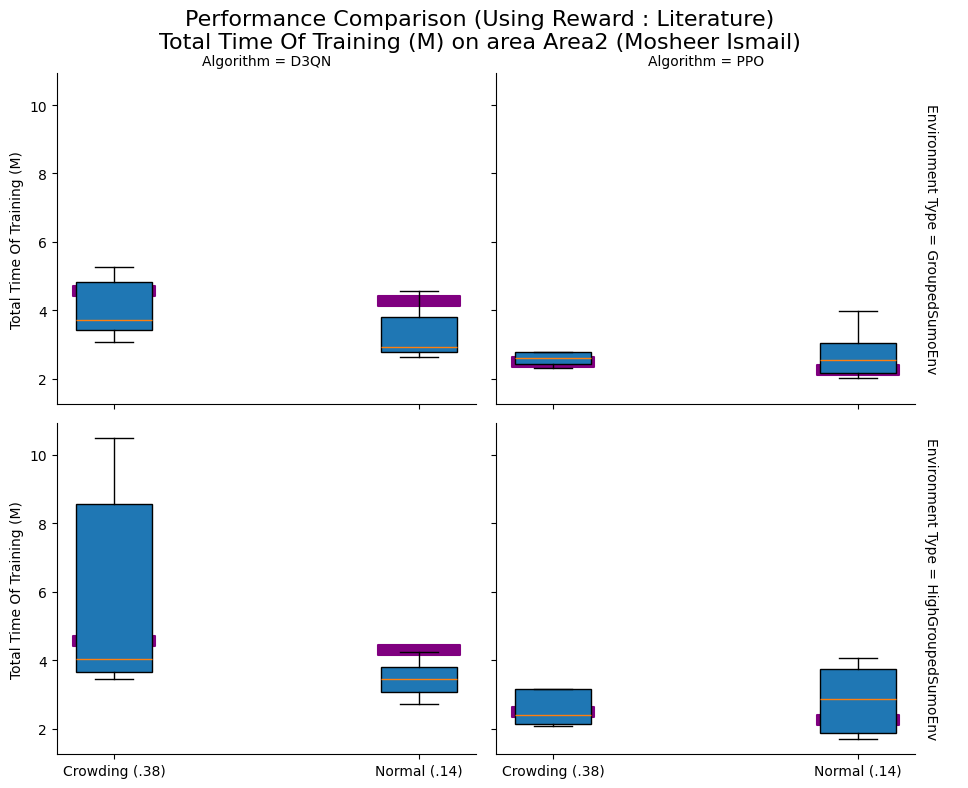

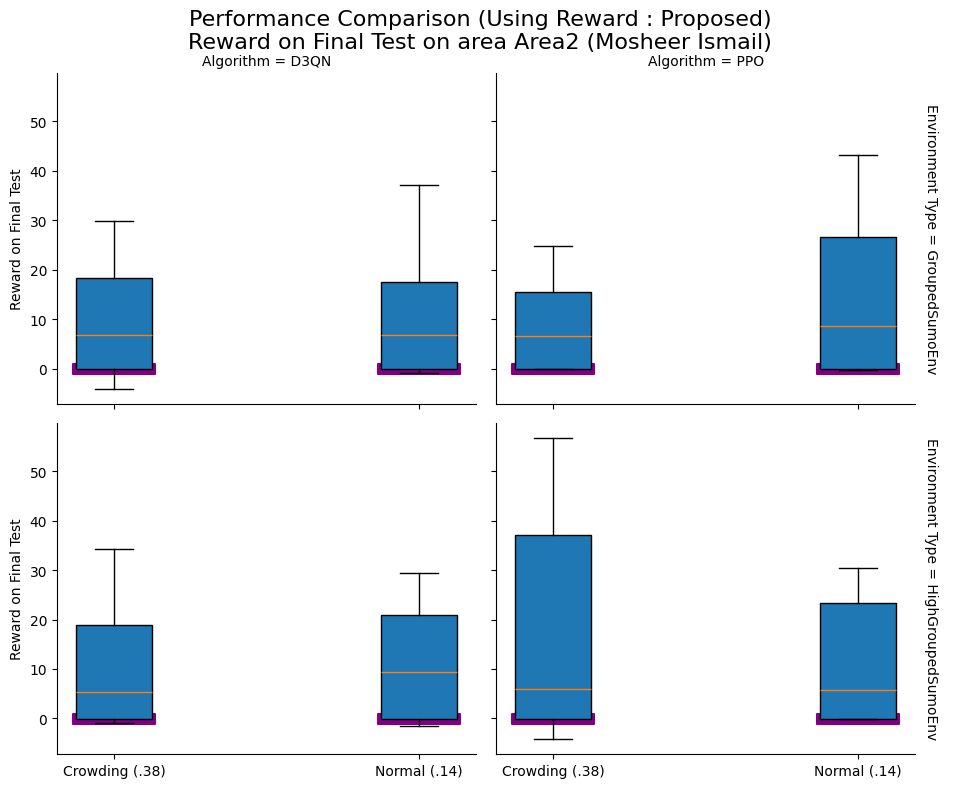

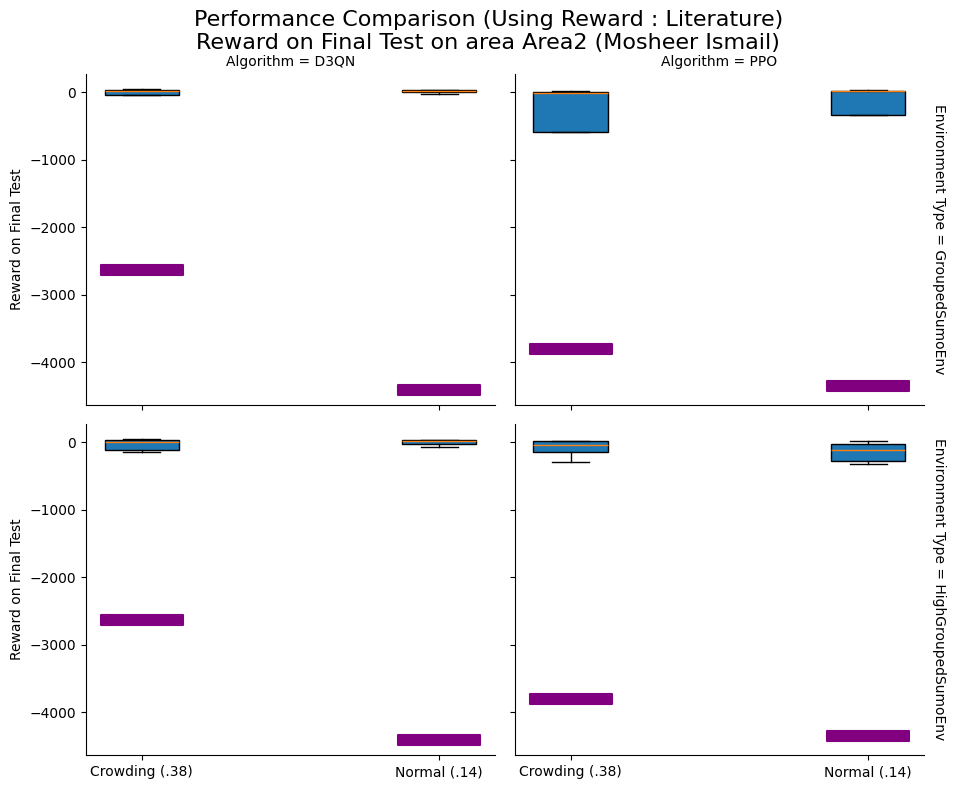

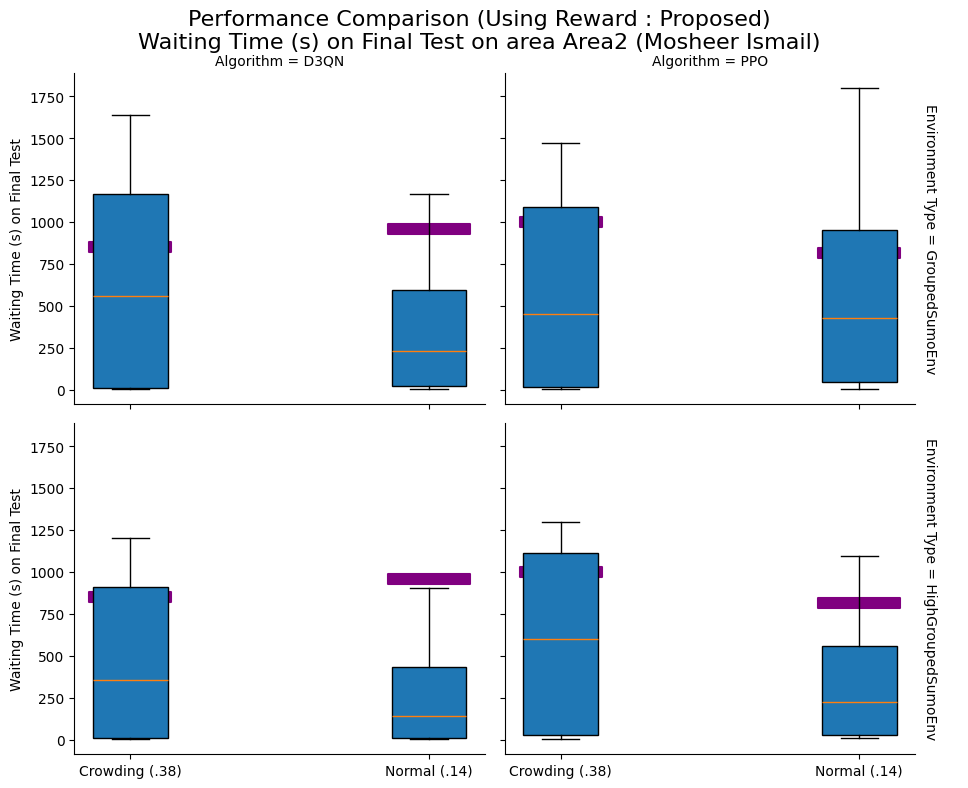

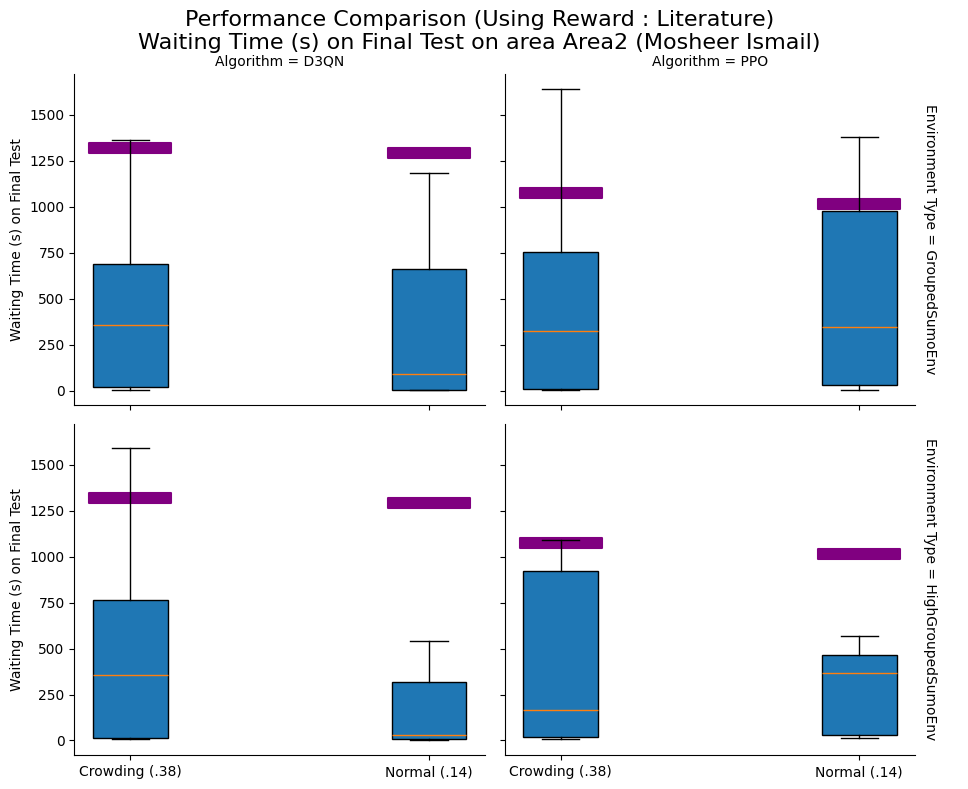

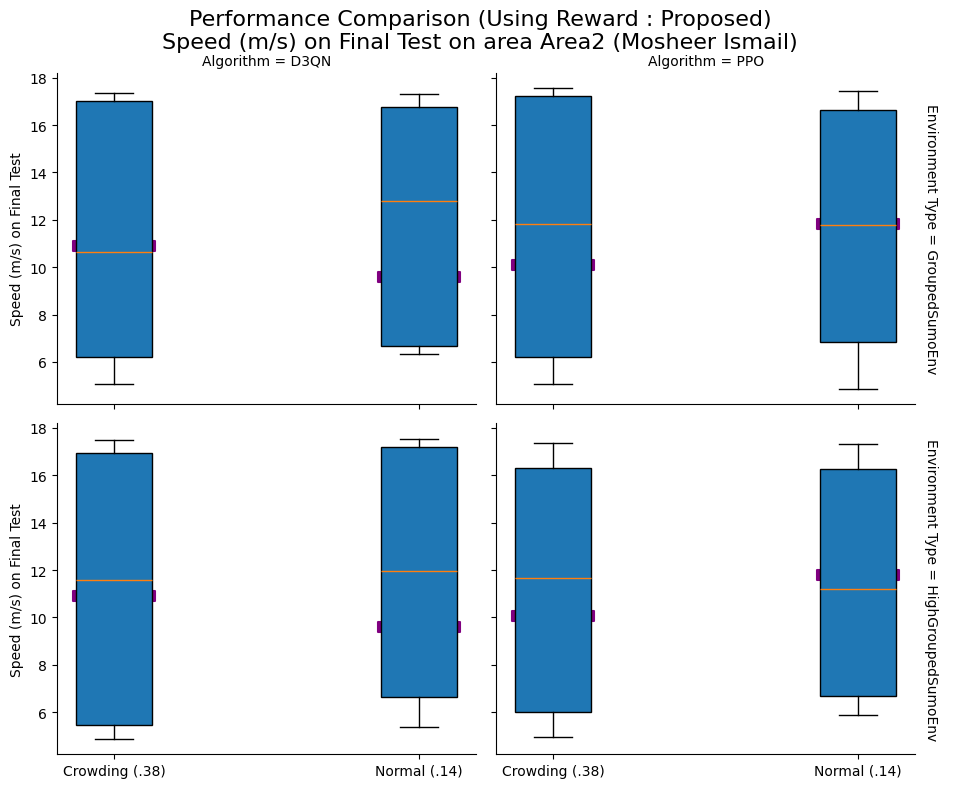

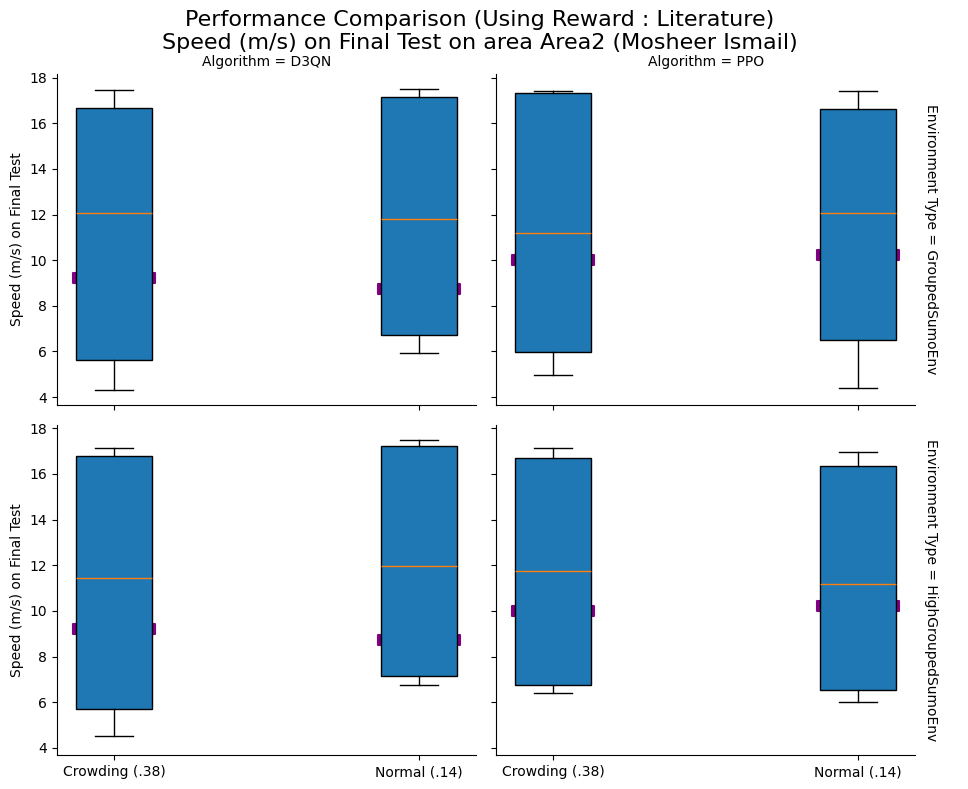

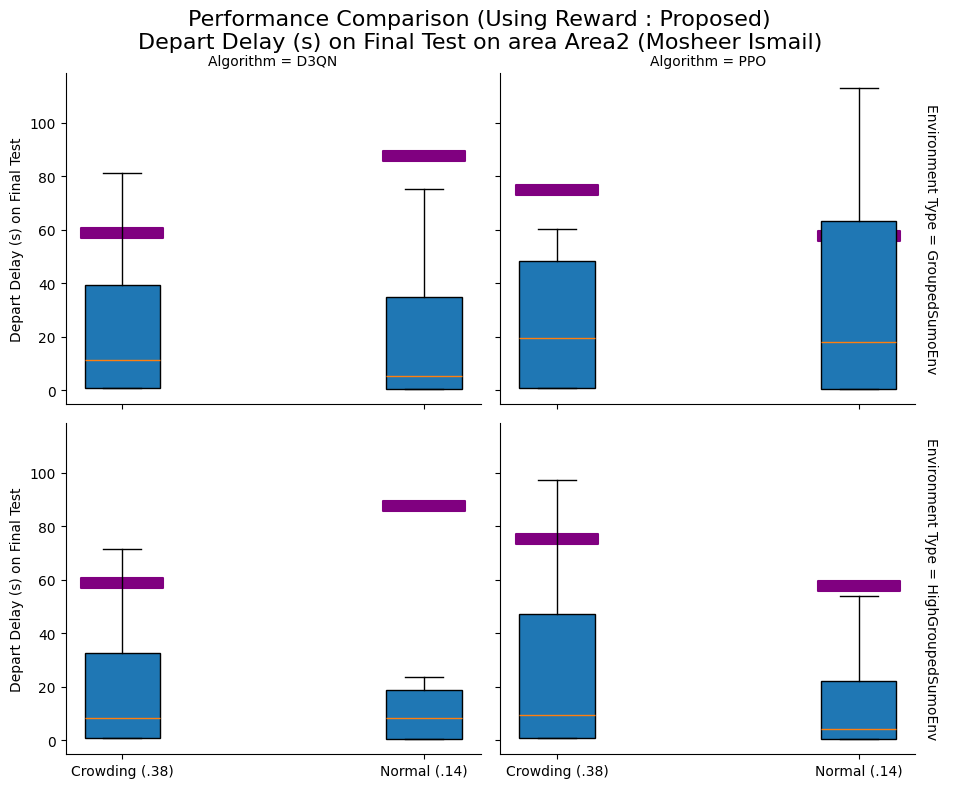

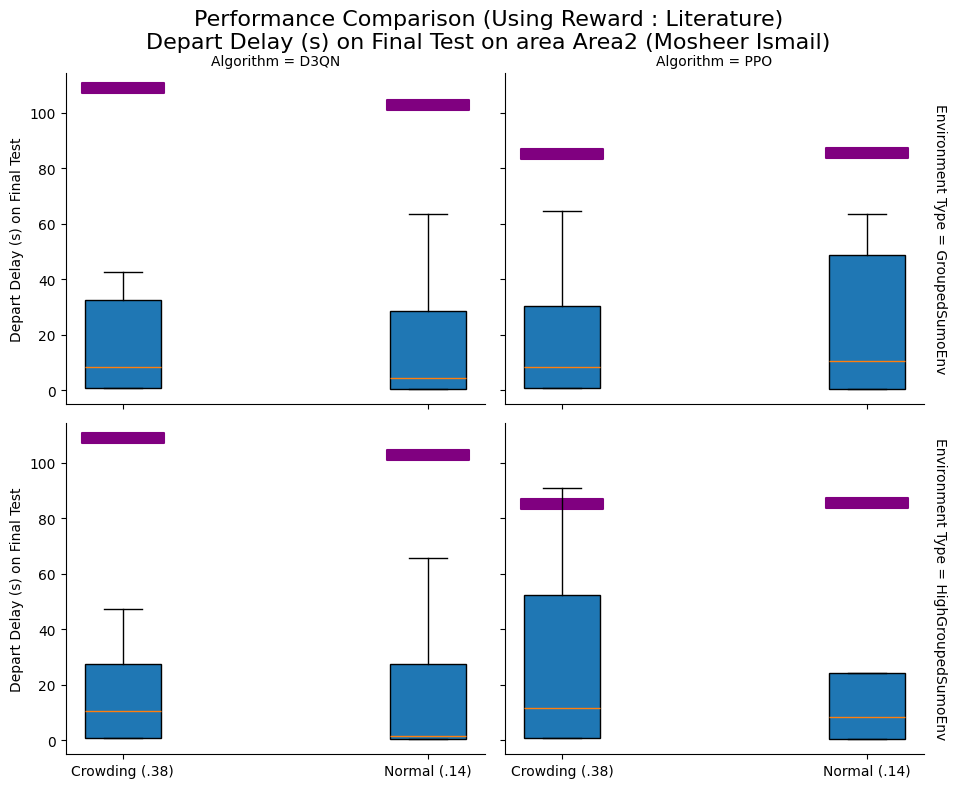

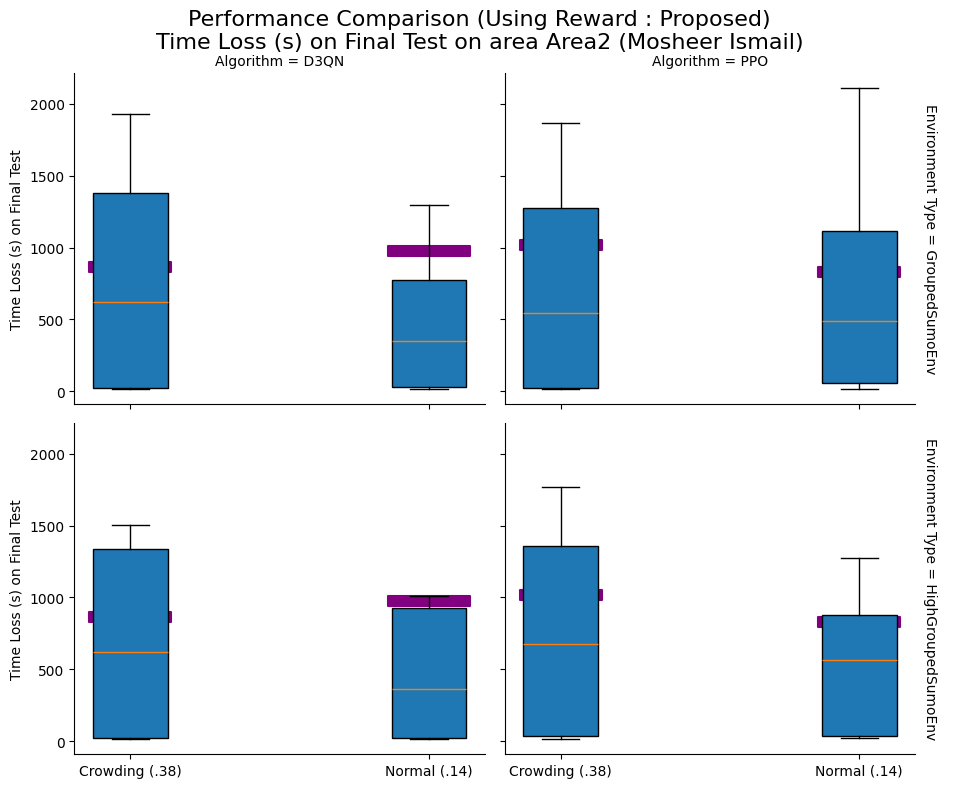

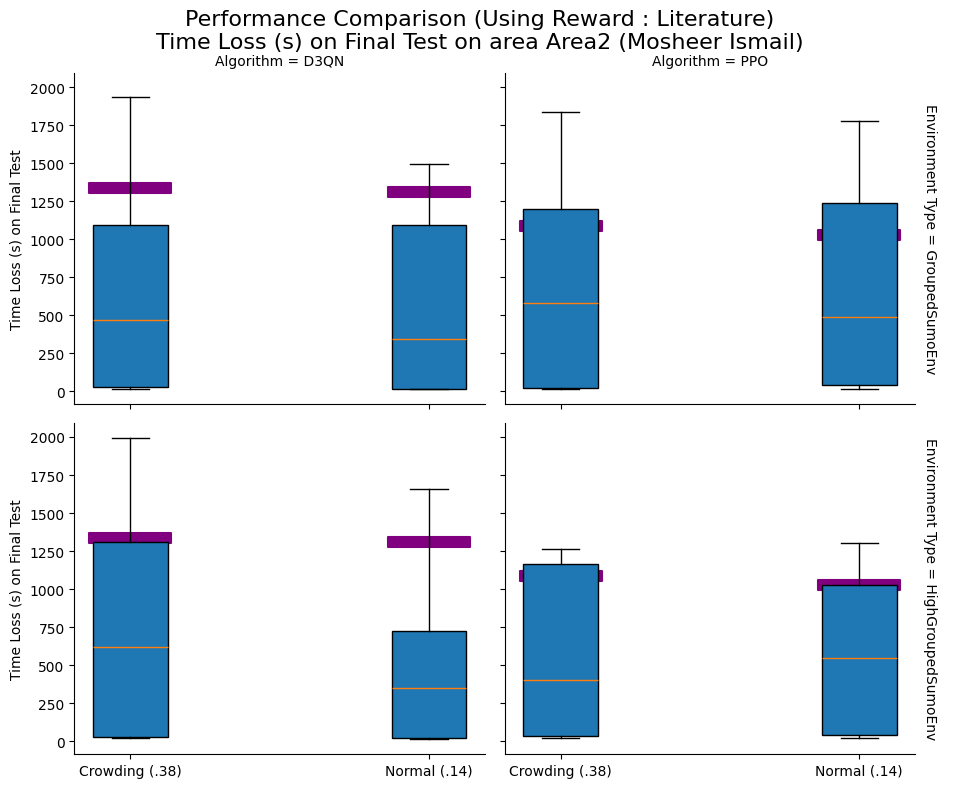

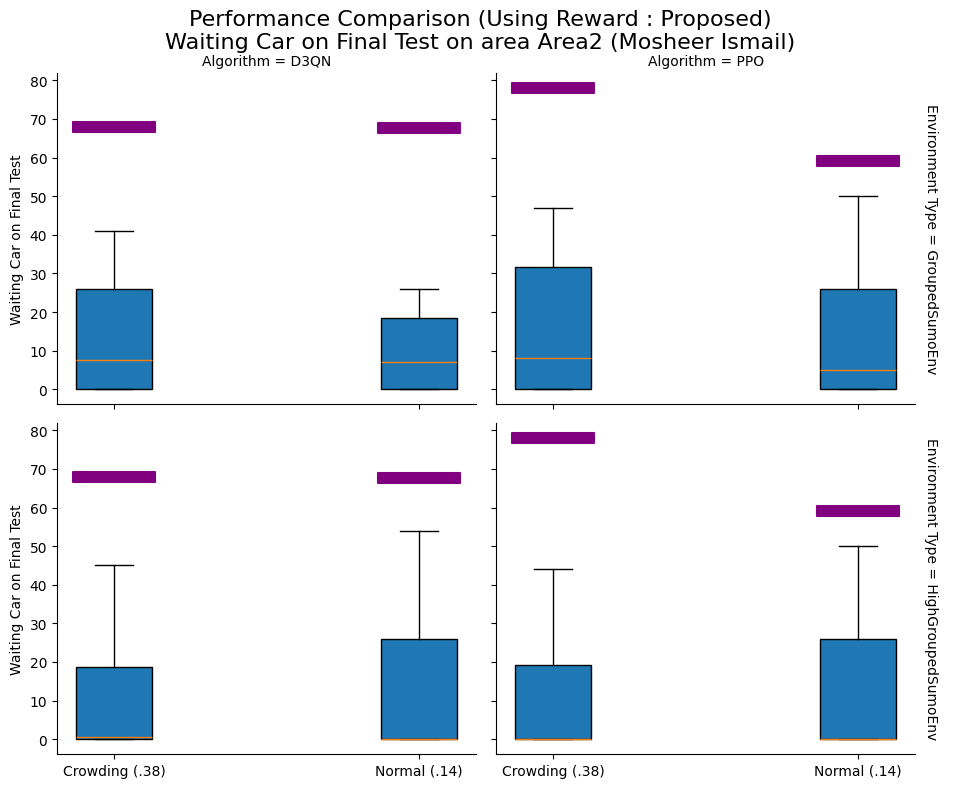

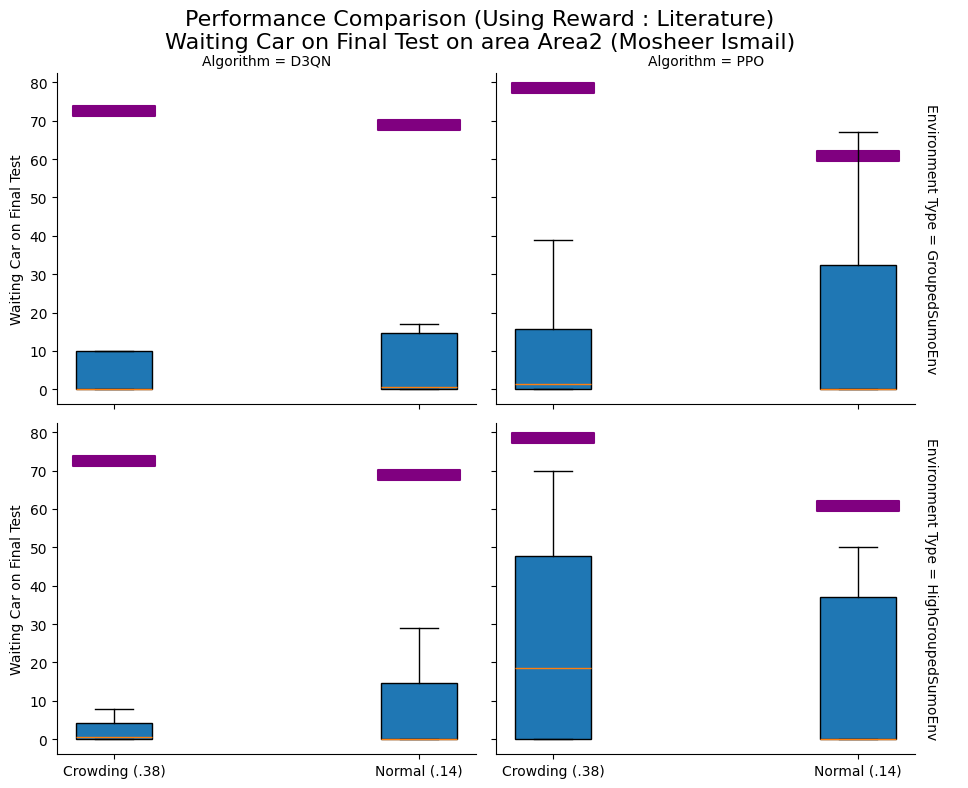

In [12]:
for metric in ['Reward of Last Episode',
       'Average Reward for Evaluated Episodes With Same Time',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car',
       'Total Time Of Training (M)', 'Reward on Final Test',
       'Waiting Time (s) on Final Test', 'Speed (m/s) on Final Test',
       'Depart Delay (s) on Final Test', 'Time Loss (s) on Final Test',
       'Waiting Car on Final Test']:
    for reward_ in ['Proposed','Literature']:
         plot_with_benchmark(data_exp,data_bench_grouped,"Area2 (Mosheer Ismail)",metric,reward= reward_)
    
    

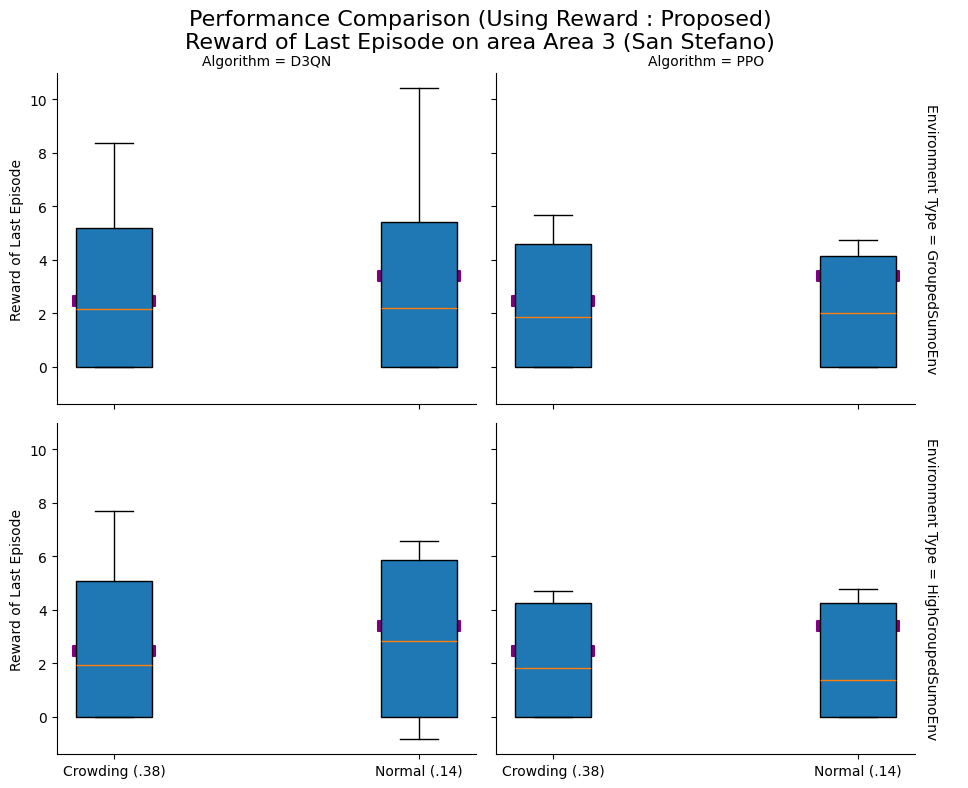

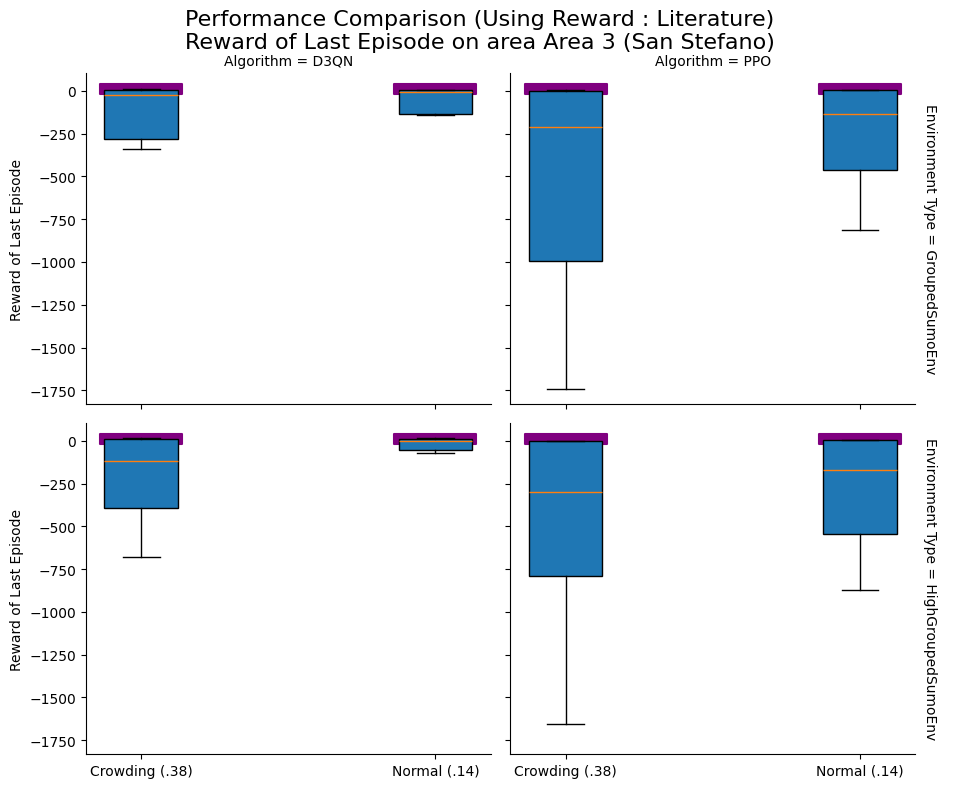

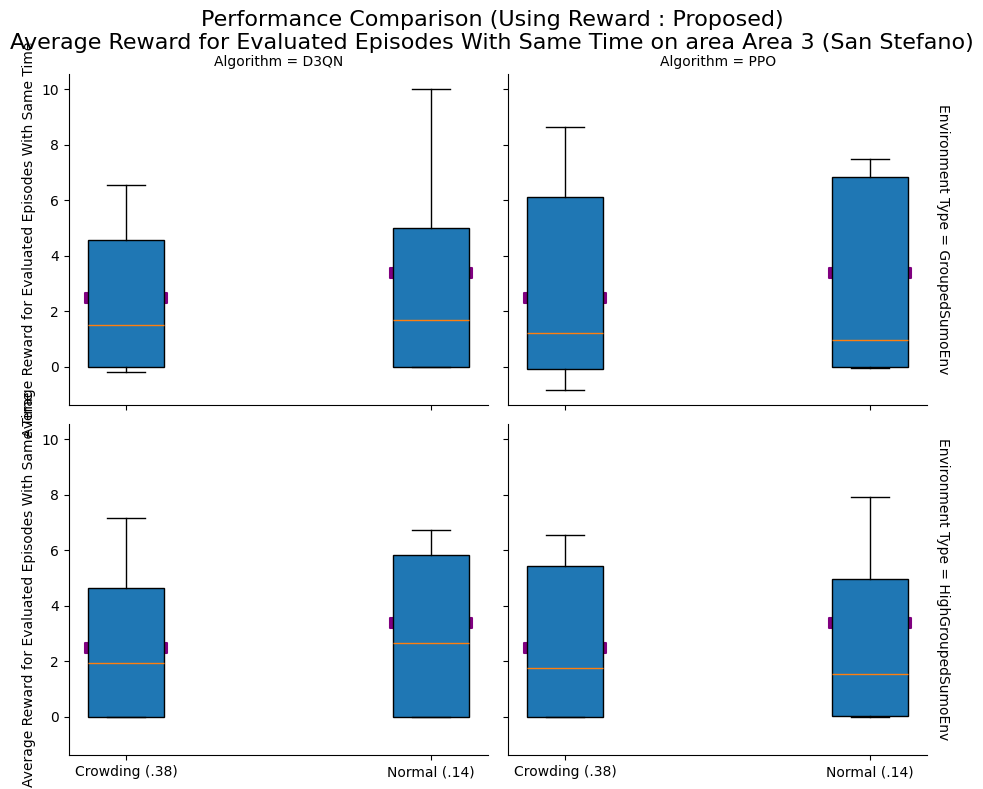

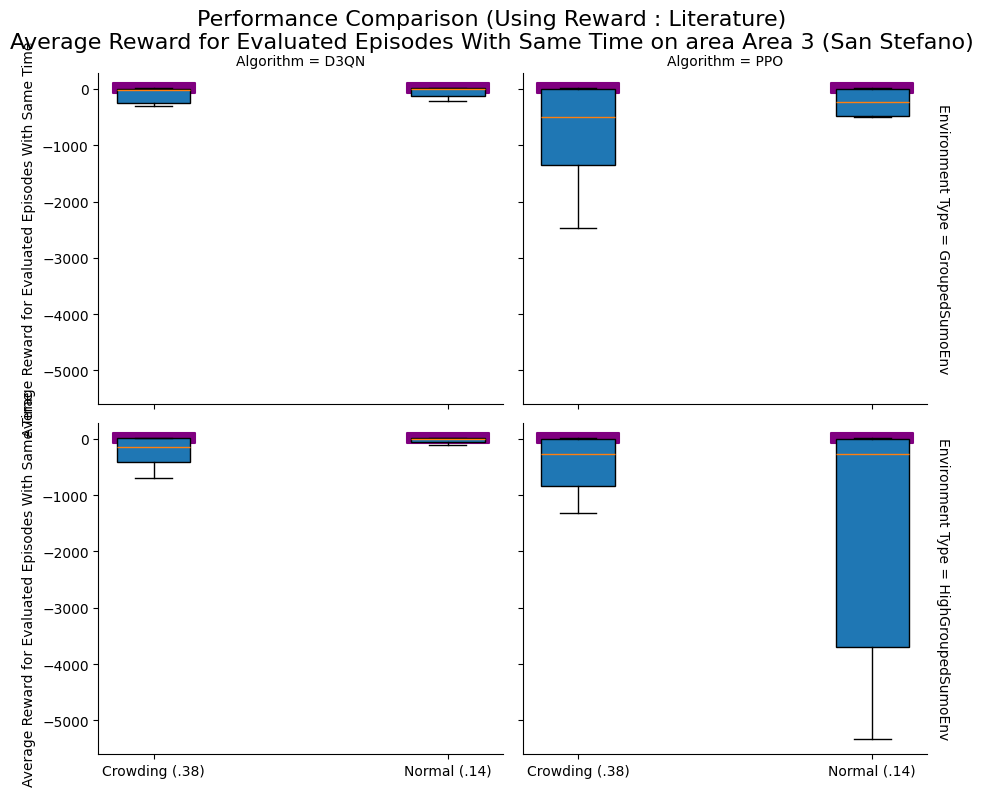

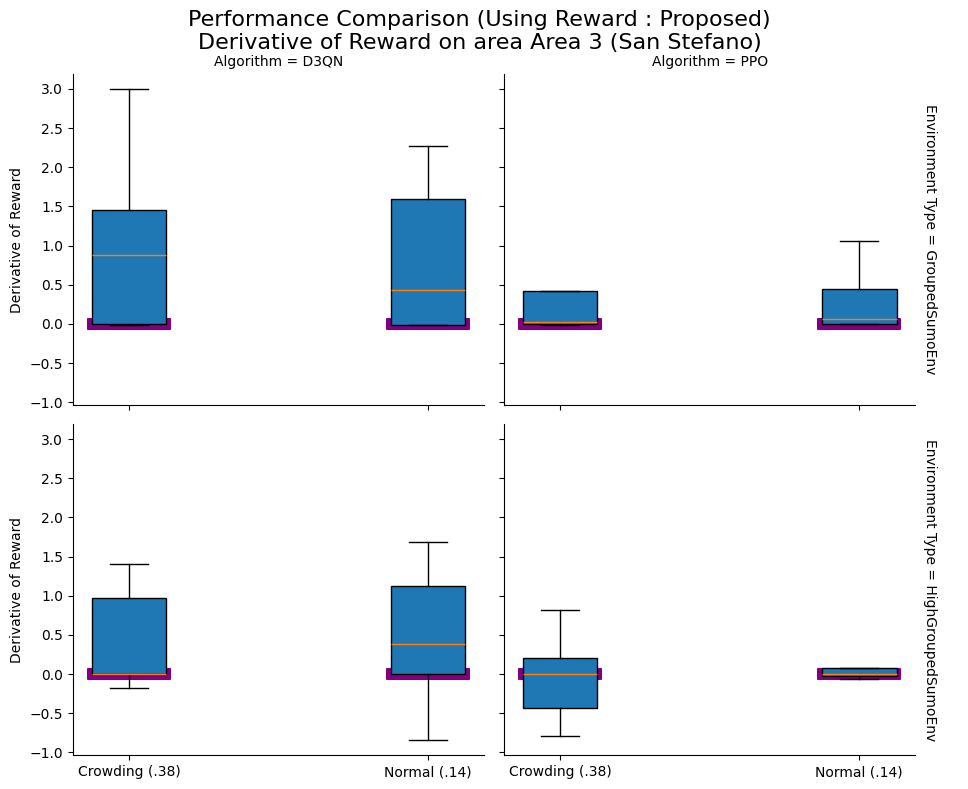

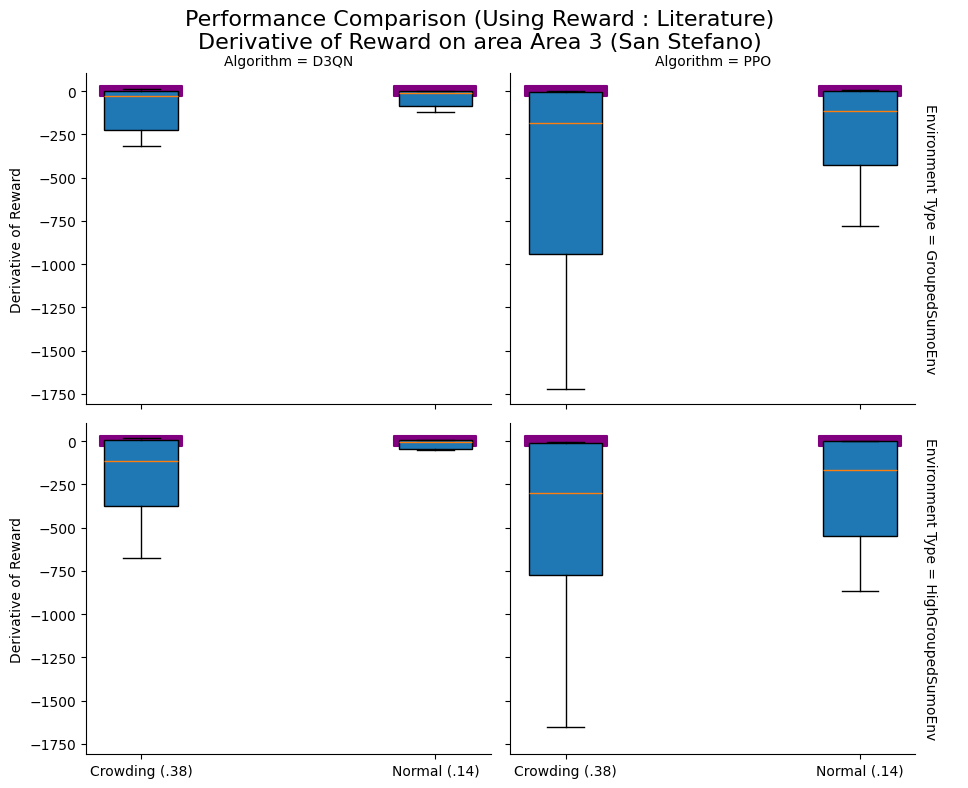

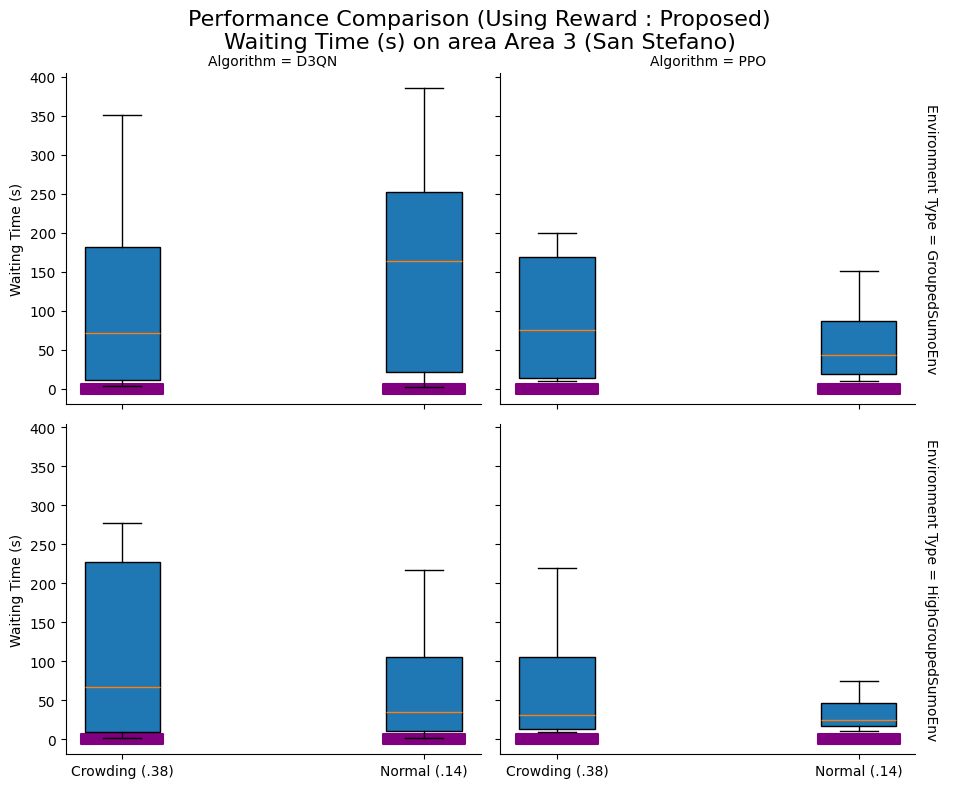

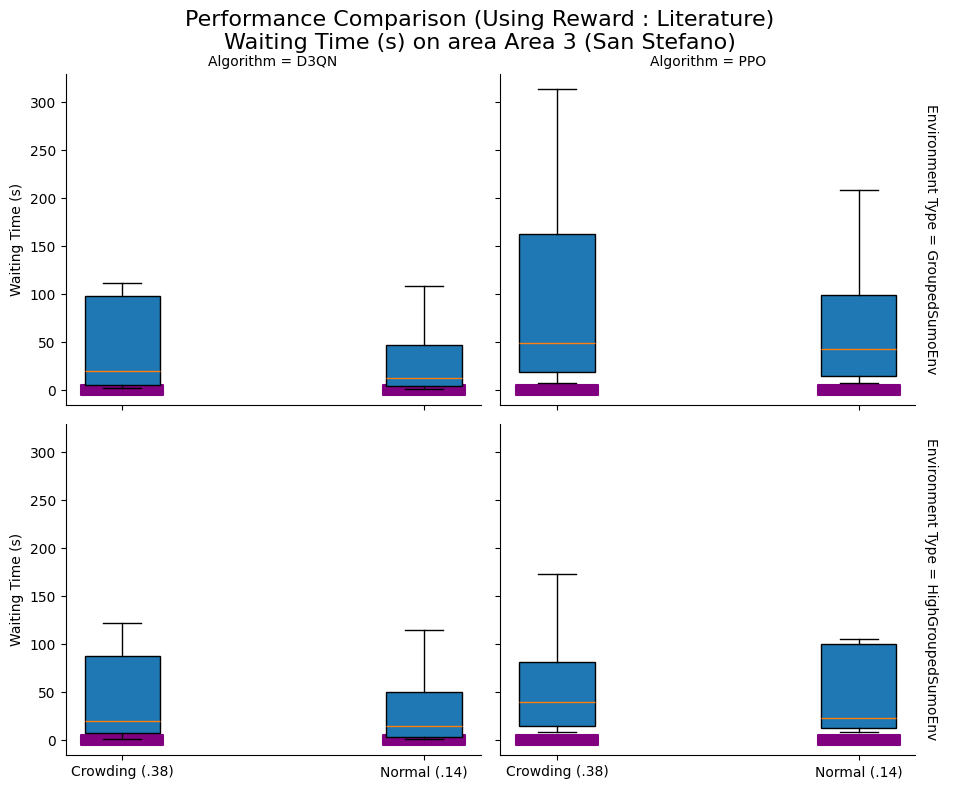

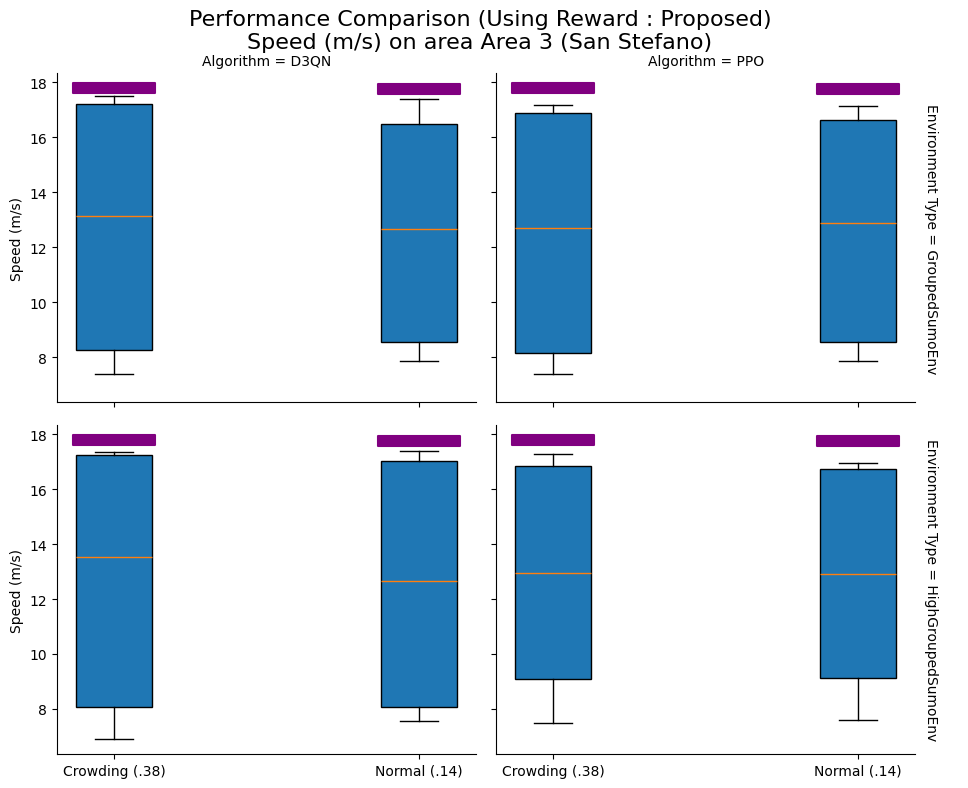

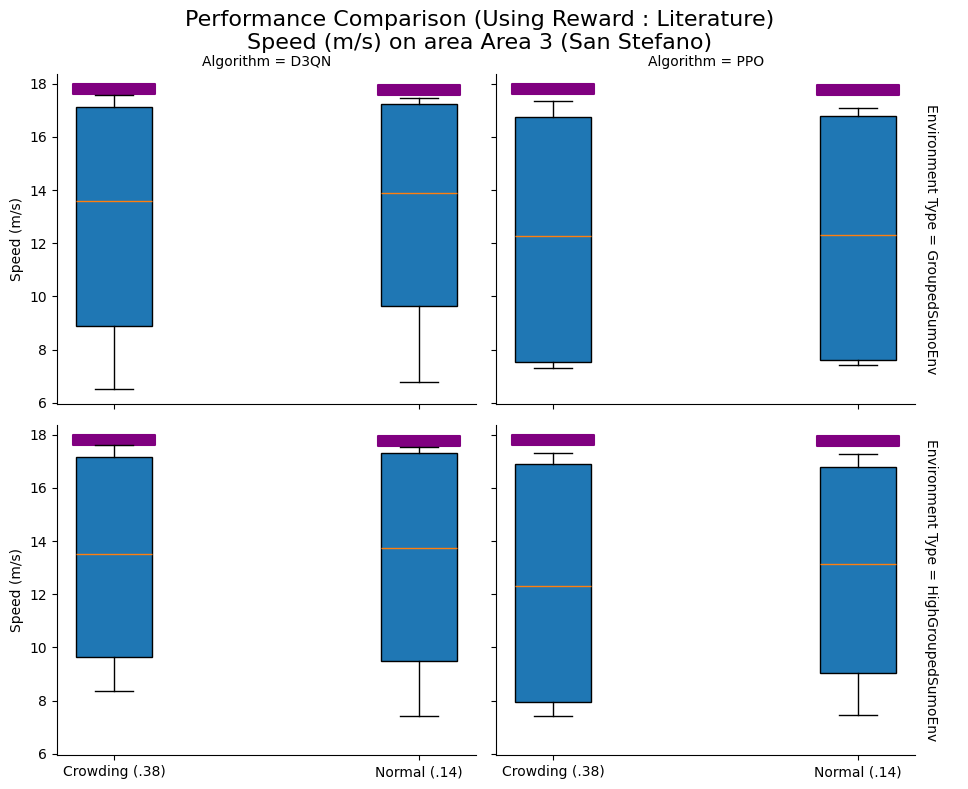

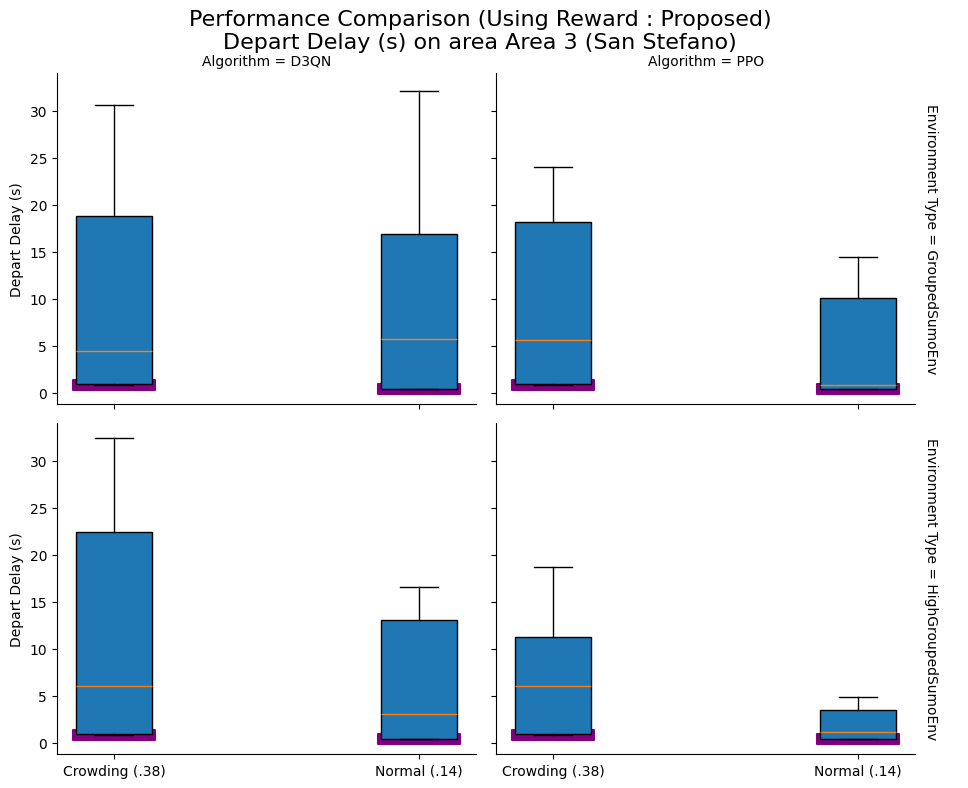

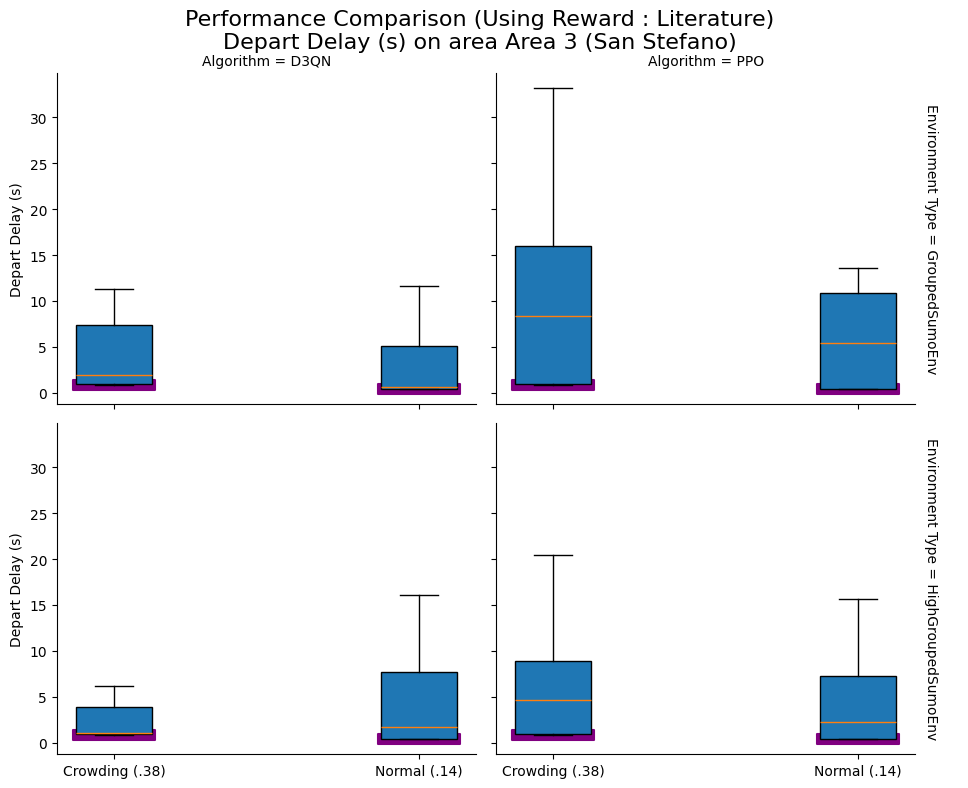

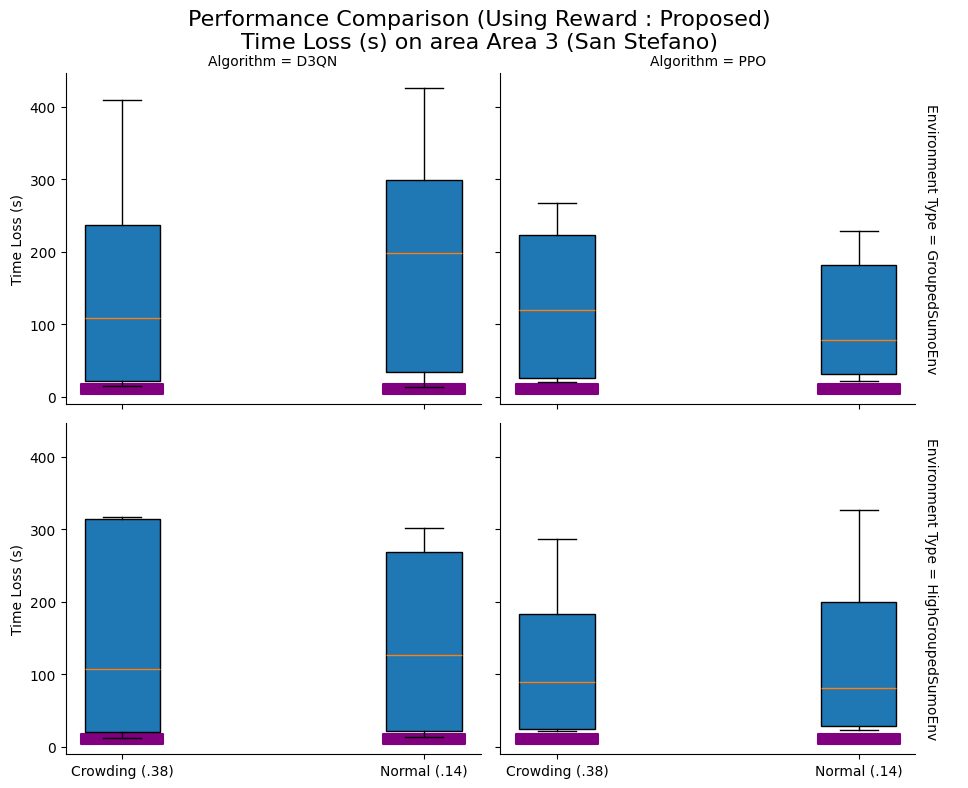

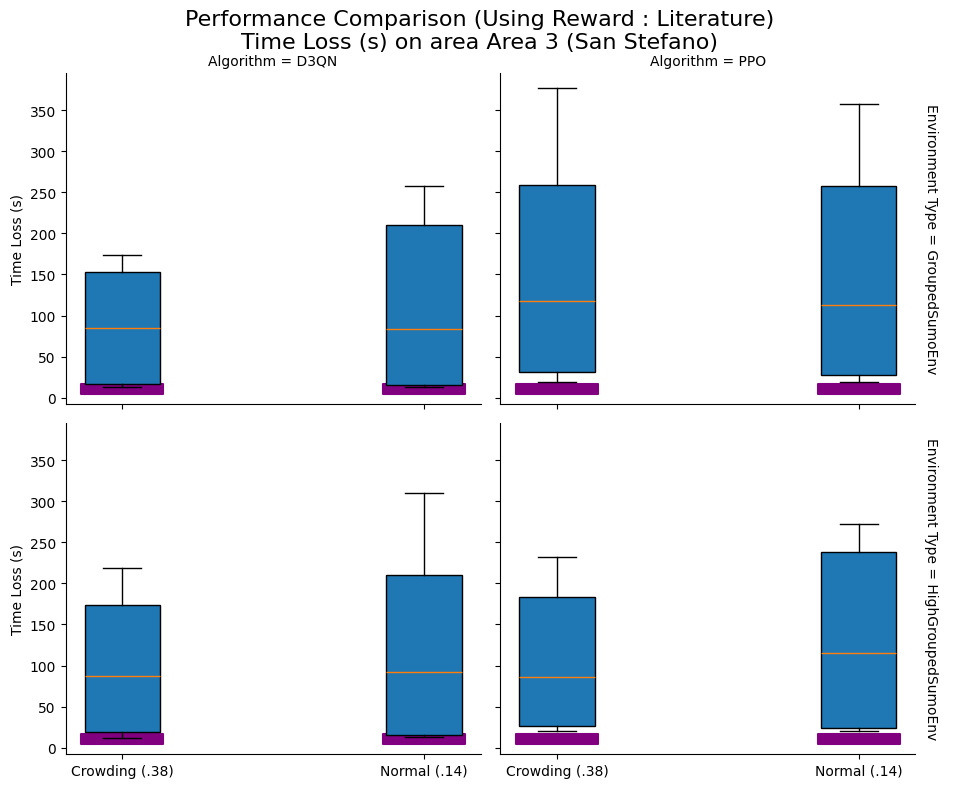

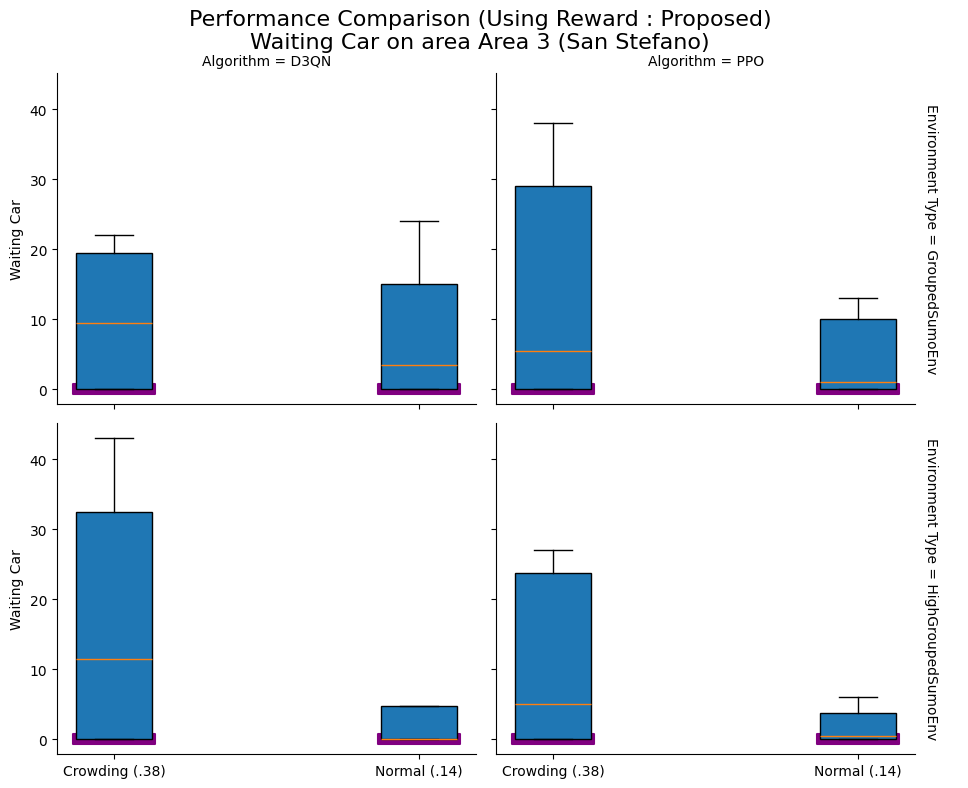

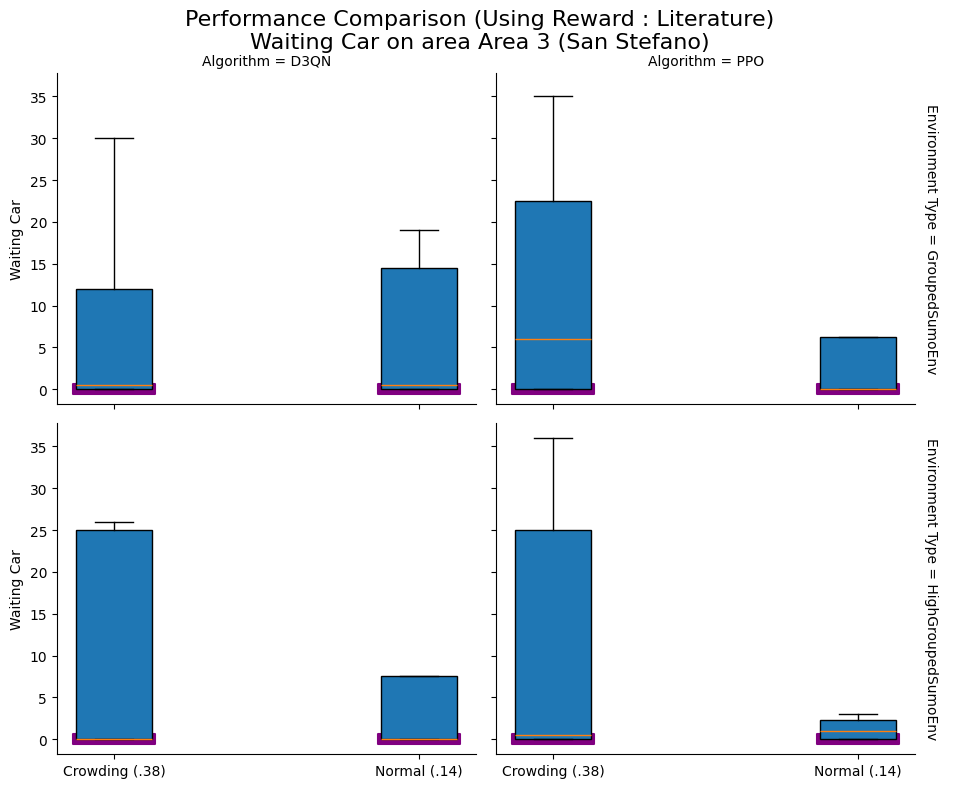

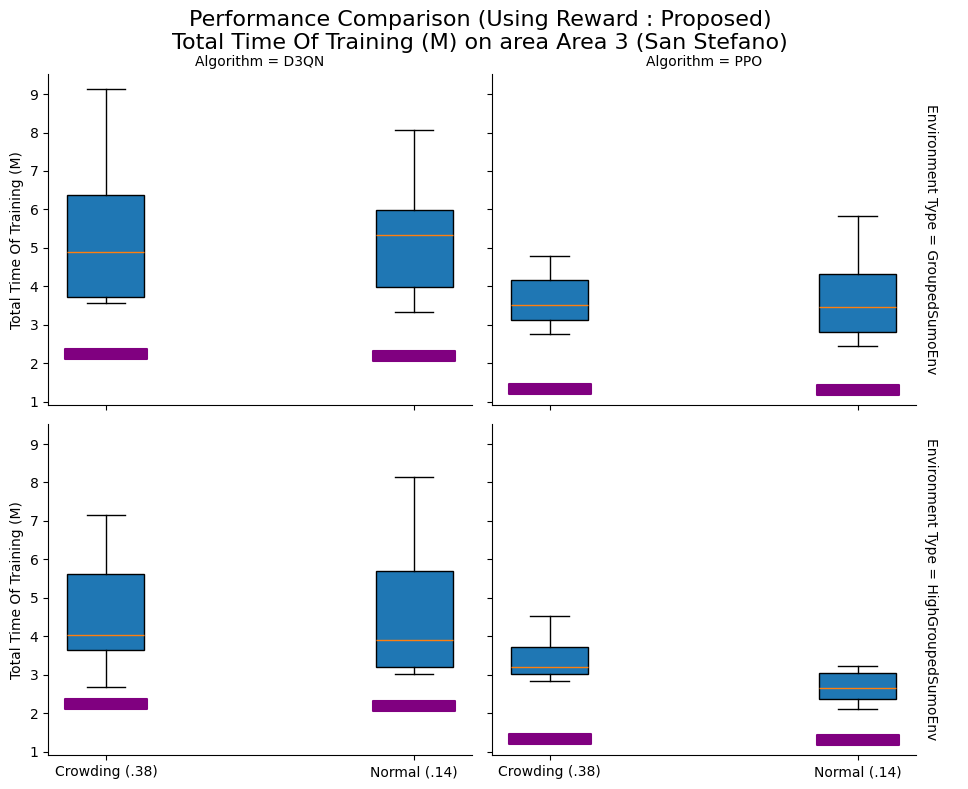

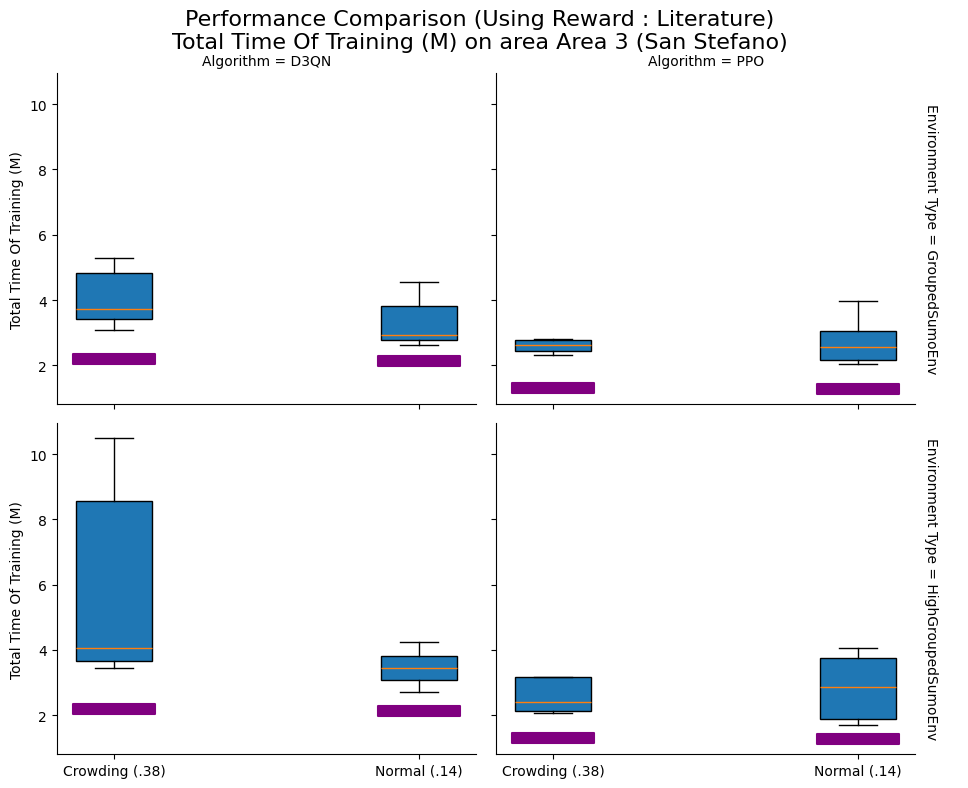

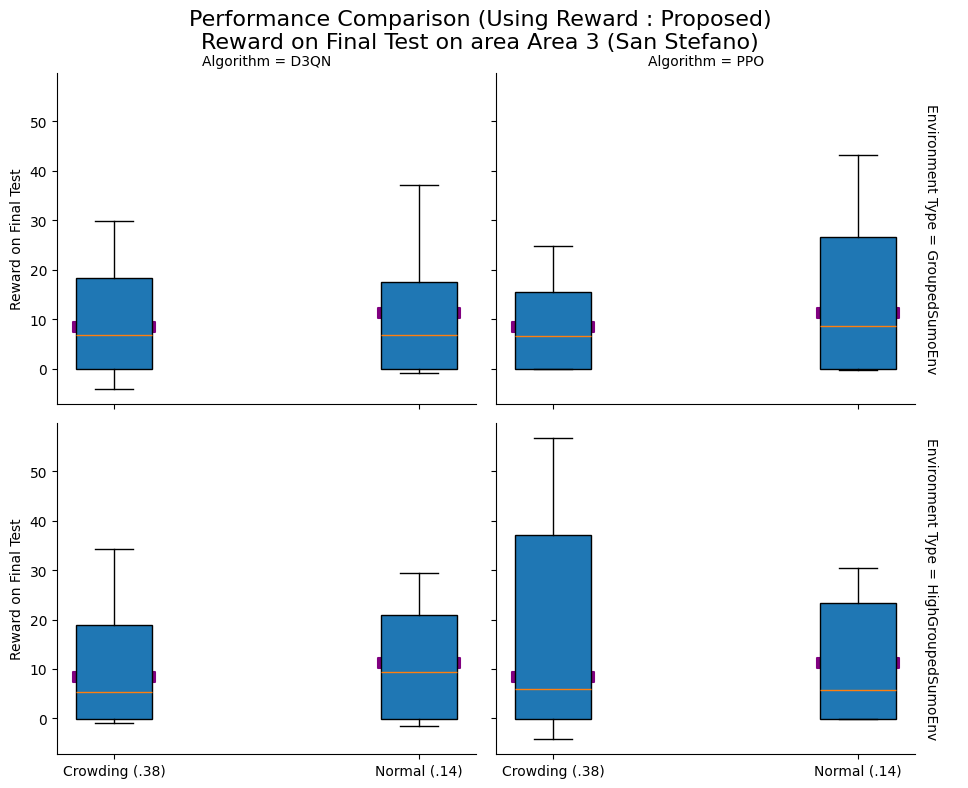

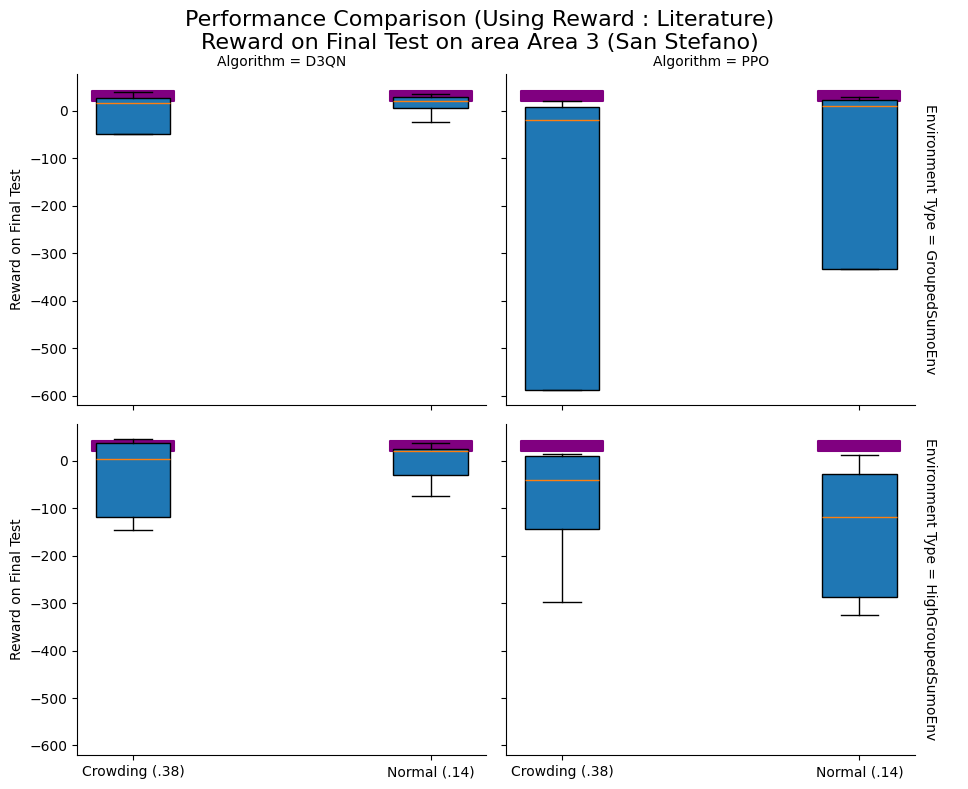

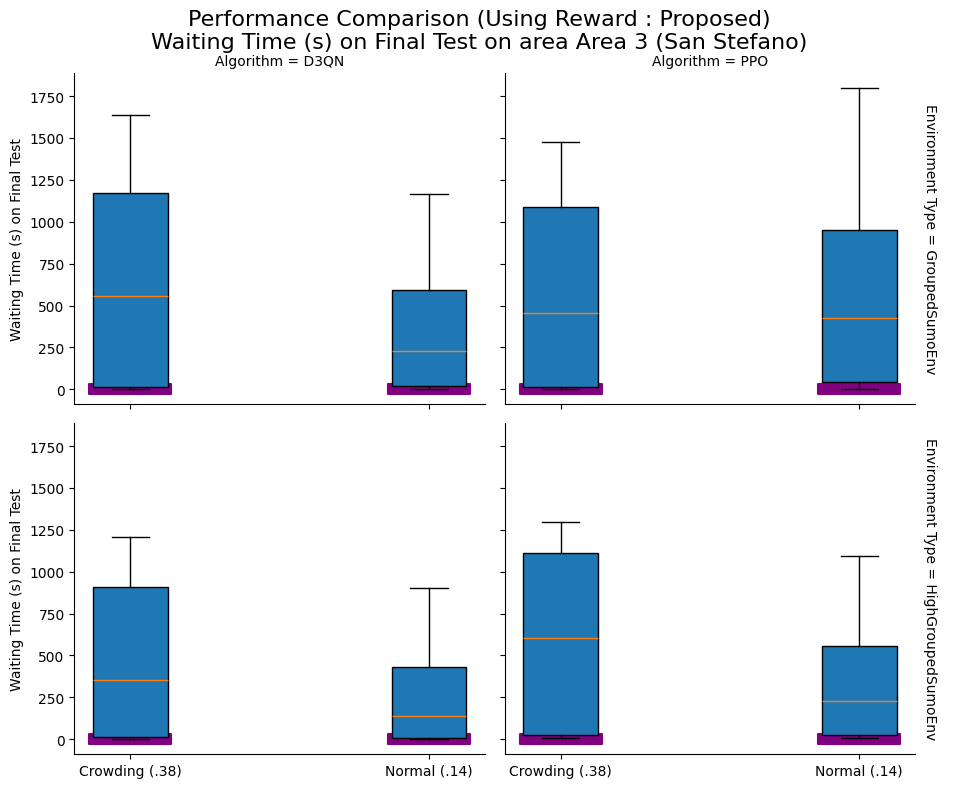

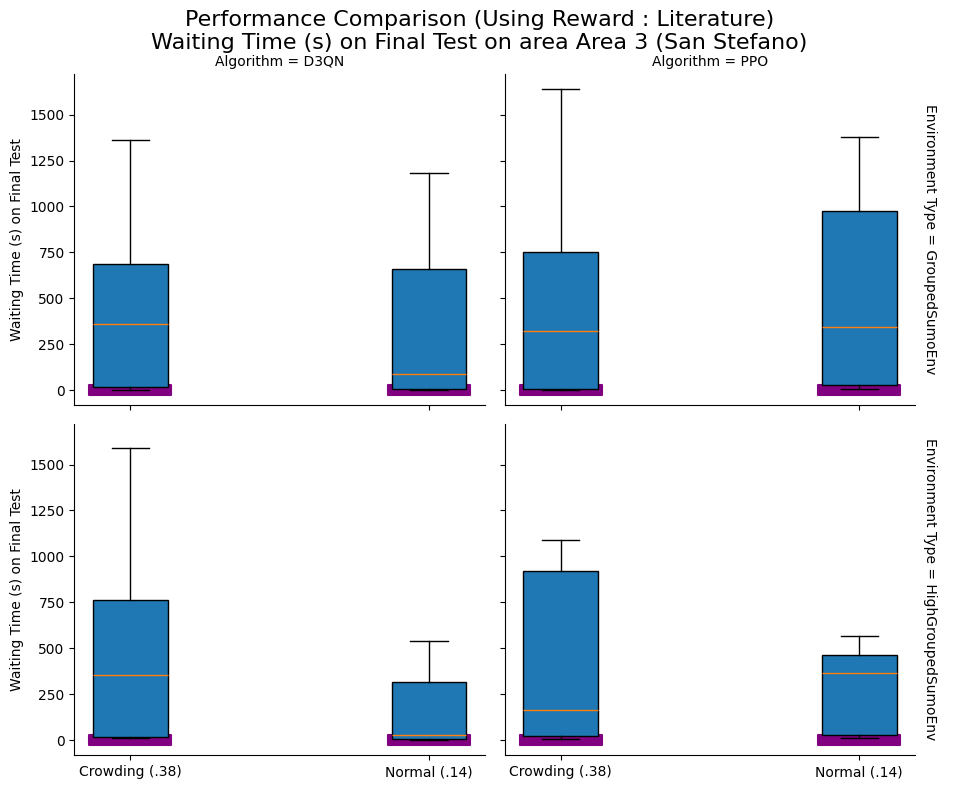

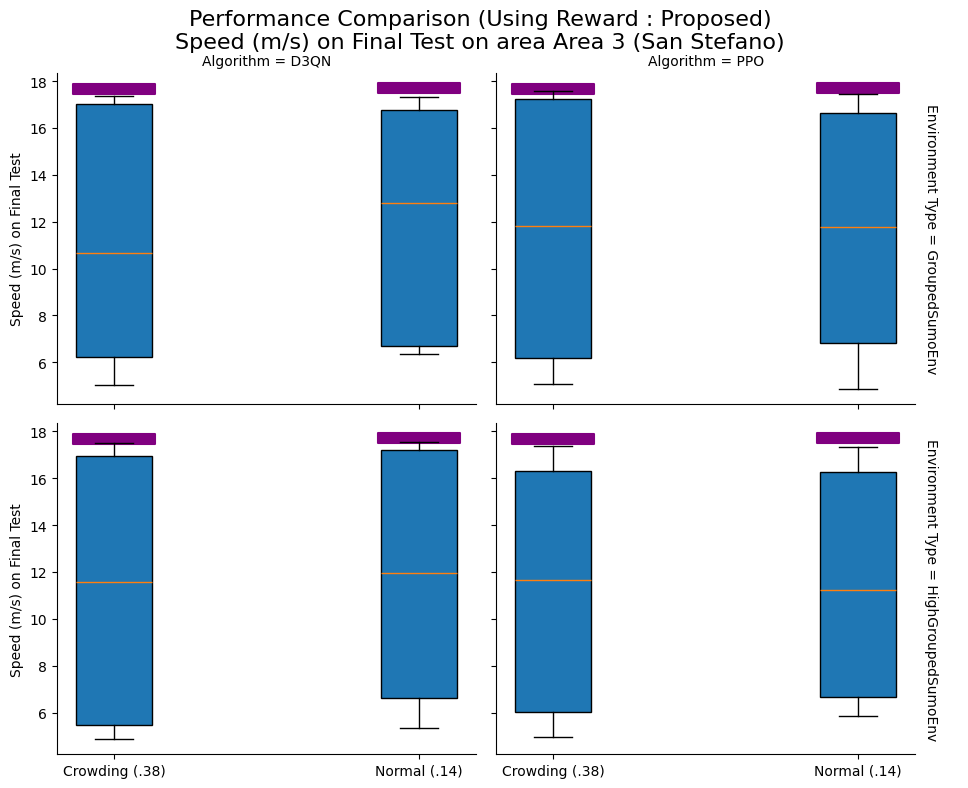

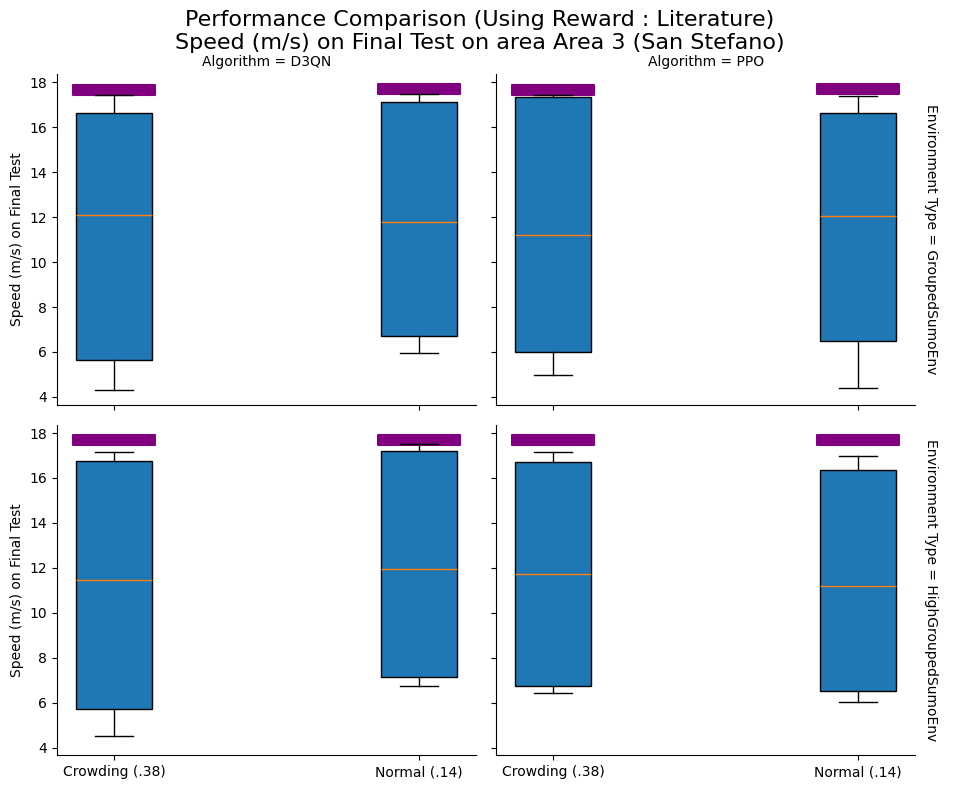

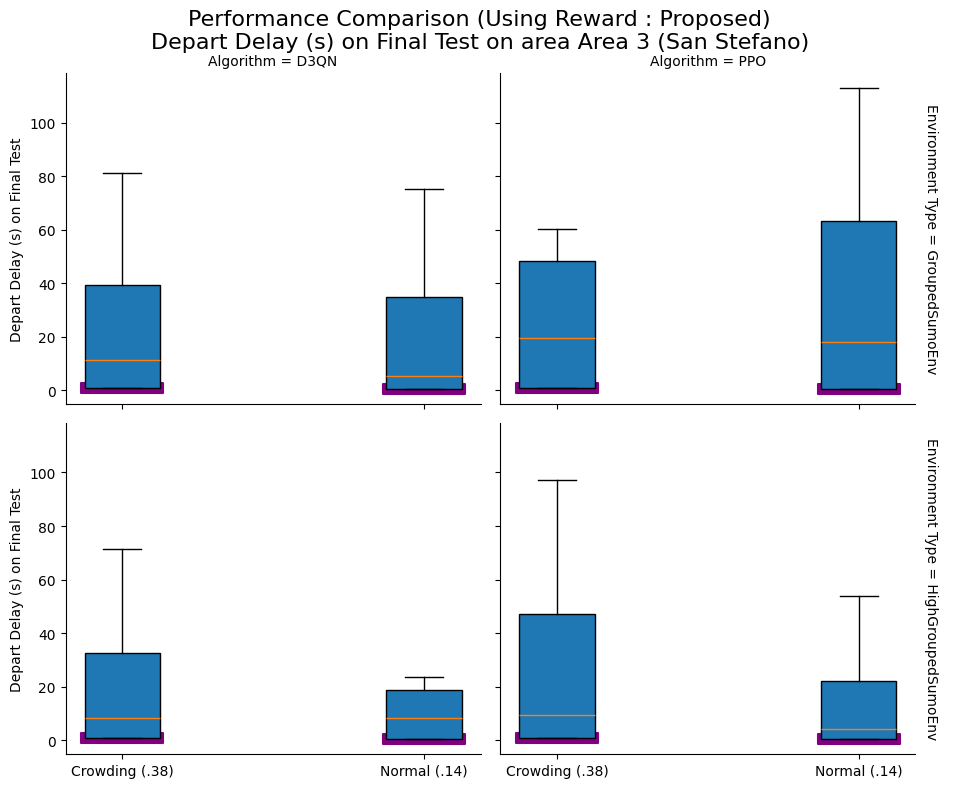

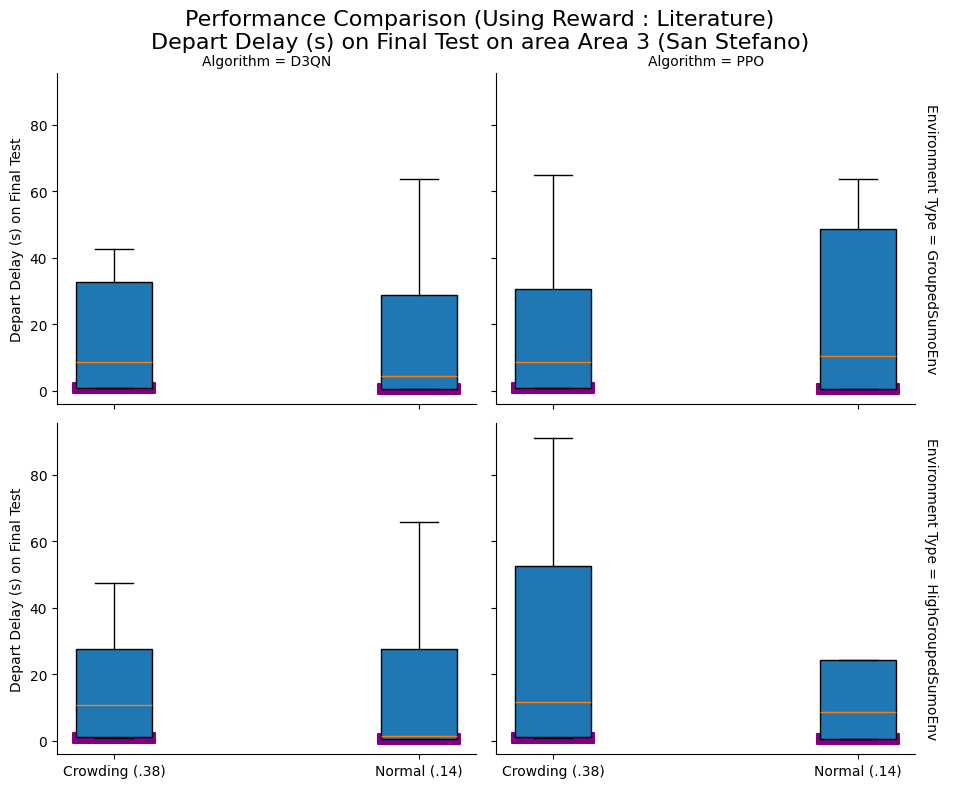

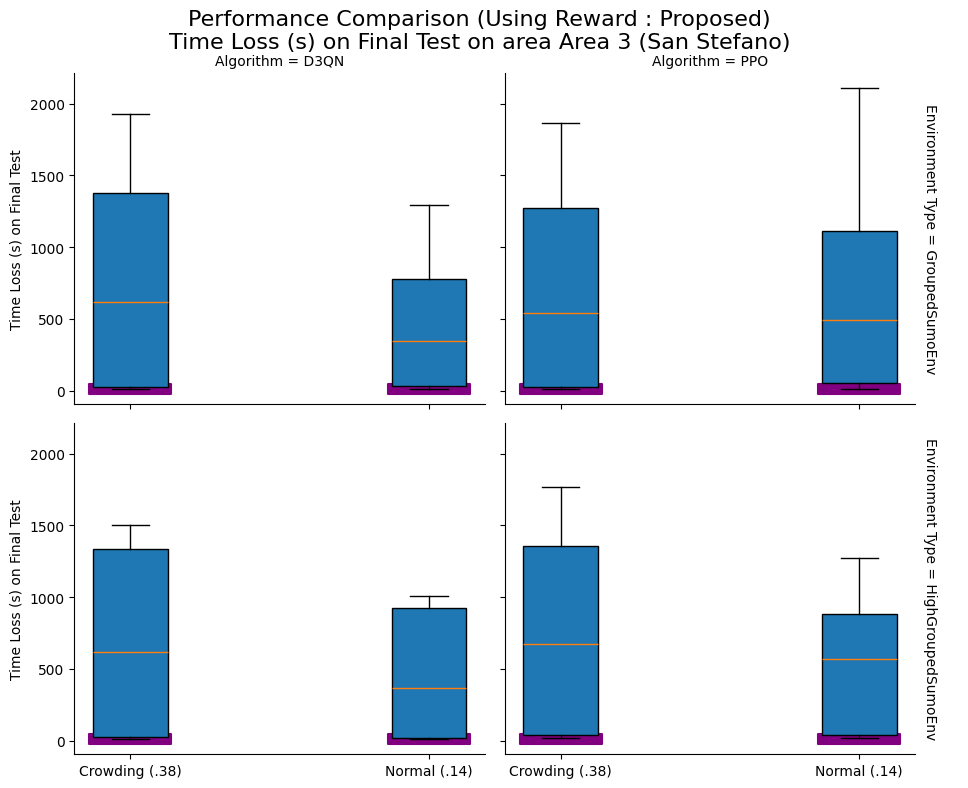

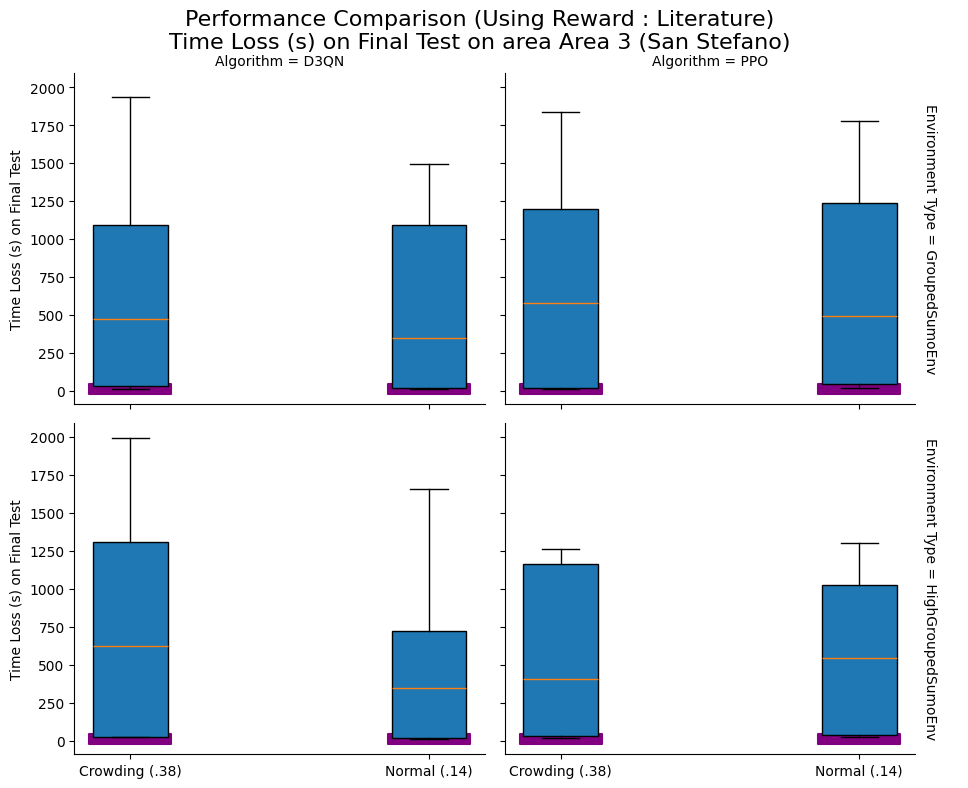

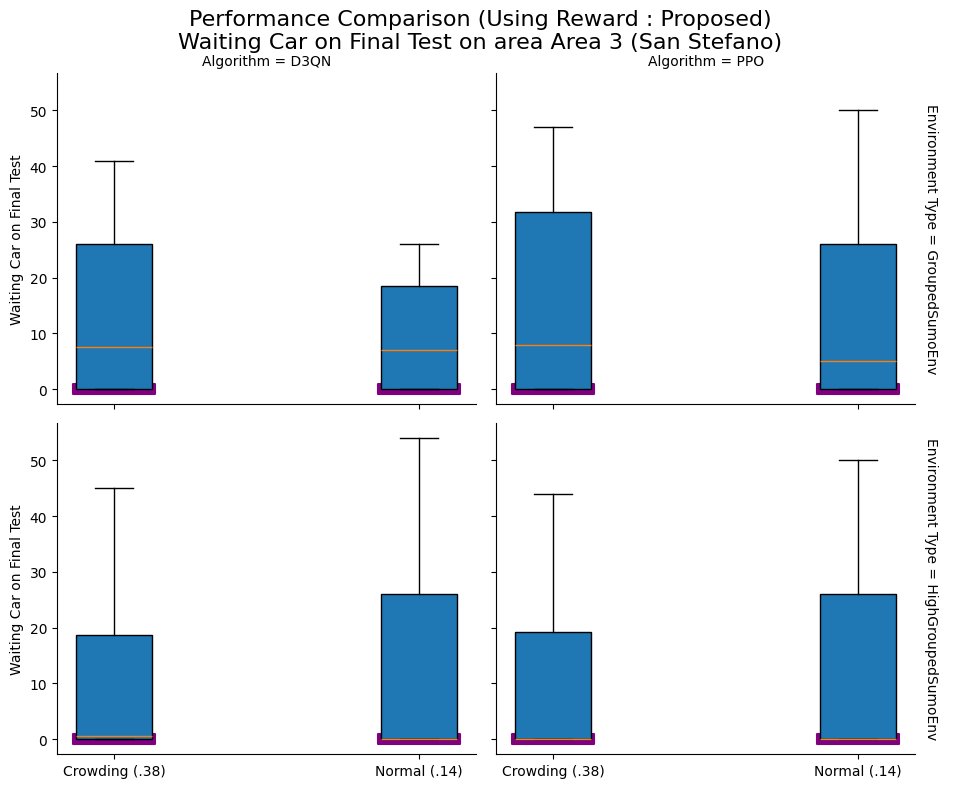

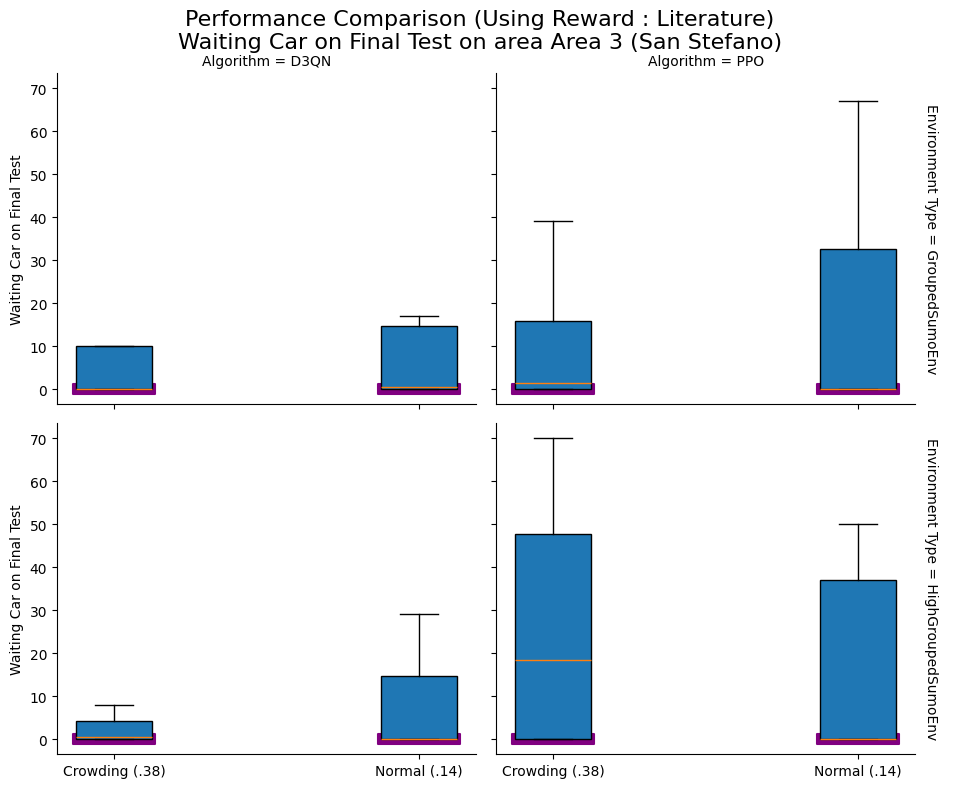

In [13]:
for metric in ['Reward of Last Episode',
       'Average Reward for Evaluated Episodes With Same Time',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car',
       'Total Time Of Training (M)', 'Reward on Final Test',
       'Waiting Time (s) on Final Test', 'Speed (m/s) on Final Test',
       'Depart Delay (s) on Final Test', 'Time Loss (s) on Final Test',
       'Waiting Car on Final Test']:
    for reward_ in ['Proposed','Literature']:
         plot_with_benchmark(data_exp,data_bench_grouped,"Area 3 (San Stefano)",metric,reward= reward_)

## Anova

In [16]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway

def simple_stat_test(df, metric, group_col):
    groups = df[group_col].unique() ##note should each group have data length > 1
    data = [df[df[group_col] == g][metric] for g in groups]
    
    if len(groups) == 2:
        stat, p = ttest_ind(*data)
        #print(f"T-test between {groups[0]} and {groups[1]}: p = {p:.4f}")
        return p 
    elif len(groups) > 2:
        stat, p = f_oneway(*data)
        #print(f"ANOVA across groups in '{group_col}': p = {p:.4f}")
        return p
    else:
        
        #print("Not enough groups to test.")
        return -1
    return -1
#tukey = pairwise_tukeyhsd(endog=df["Reward"], groups=df["Algorithm"], alpha=0.05)



In [17]:
alpha = .03

In [18]:
from tabulate import tabulate
from colorama import Fore, Style

headers = ["Area", "Reward", "Traffic Scale", "Algorithm", 'Reward of Last Episode','Waiting Time (s)','Speed (m/s)', 'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']
table_data = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):
                analysis_mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] ==scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )

                data_i_exp = data_exp[analysis_mask]
            

                reward_test = simple_stat_test(data_i_exp, "Average Reward for Evaluated Episodes With Same Time","Environment Type") 
                reward_color = Fore.RED if reward_test < alpha else Fore.GREEN

                waiting_test = simple_stat_test(data_i_exp, "Waiting Time (s)","Environment Type") 
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN

                spd_test = simple_stat_test(data_i_exp, 'Speed (m/s)',"Environment Type") 
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN

                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type") 
                depart_color = Fore.RED if depart_test < alpha else Fore.GREEN

                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type") 
                Tloss_color = Fore.RED if Tloss_test < alpha else Fore.GREEN

                carWait_test = simple_stat_test(data_i_exp, 'Waiting Car',"Environment Type") 
                carWait_color = Fore.RED if carWait_test < alpha else Fore.GREEN

                table_data.append([
                        f"{Fore.CYAN} {Area} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Reward} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {scale} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Algorithm} {Style.RESET_ALL}",
                        f"{reward_color} {reward_test} {Style.RESET_ALL}",
                        f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                        f"{spd_color}{spd_test}{Style.RESET_ALL}",
                        f"{depart_color}{depart_test}{Style.RESET_ALL}",
                        f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                        f"{carWait_color}{carWait_test}{Style.RESET_ALL}"

                ])
            

table =tabulate(table_data, headers=headers, tablefmt="grid")

print(table)

+--------------------------+--------------+------------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                     | Reward       | Traffic Scale    | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+==========================+==============+==================+=============+==========================+====================+===============+====================+=================+===============+
|  Area 3 (San Stefano)    |  Proposed    |  Normal (.14)    |  PPO        |                0.782093  |          0.861661  |      0.875426 |           1        |       0.869119  |    nan        |
+--------------------------+--------------+------------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
|  Area2 (Mosheer Is

In [ ]:
# Same as above but save to XLSX without colors
import pandas as pd
from tabulate import tabulate
from colorama import Fore, Style

headers = [
    "Area", "Reward", "Traffic Scale", "Algorithm",
    'Reward of Last Episode','Waiting Time (s)','Speed (m/s)',
    'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car'
]

table_data_print = []
table_data_xlsx = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):

                mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] == scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )
                data_i_exp = data_exp[mask]

                reward_test = simple_stat_test(data_i_exp,"Average Reward for Evaluated Episodes With Same Time","Environment Type")
                waiting_test = simple_stat_test(data_i_exp,"Waiting Time (s)","Environment Type")
                spd_test = simple_stat_test(data_i_exp,'Speed (m/s)',"Environment Type")
                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type")
                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type")
                carWait_test = simple_stat_test(data_i_exp,'Waiting Car',"Environment Type")

                reward_color = Fore.RED if reward_test<alpha else Fore.GREEN
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN
                depart_color = Fore.RED if depart_test<alpha else Fore.GREEN
                Tloss_color = Fore.RED if Tloss_test<alpha else Fore.GREEN
                carWait_color = Fore.RED if carWait_test<alpha else Fore.GREEN

                # Colorful row for terminal
                table_data_print.append([
                    f"{Fore.CYAN}{Area}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Reward}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{scale}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Algorithm}{Style.RESET_ALL}",
                    f"{reward_color}{reward_test}{Style.RESET_ALL}",
                    f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                    f"{spd_color}{spd_test}{Style.RESET_ALL}",
                    f"{depart_color}{depart_test}{Style.RESET_ALL}",
                    f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                    f"{carWait_color}{carWait_test}{Style.RESET_ALL}"
                ])

                # Clean row for Excel
                table_data_xlsx.append([
                    Area, Reward, scale, Algorithm,
                    reward_test, waiting_test, spd_test,
                    depart_test, Tloss_test, carWait_test
                ])

# Print table
print(tabulate(table_data_print, headers=headers, tablefmt="grid"))

# Save XLSX
df = pd.DataFrame(table_data_xlsx, columns=headers)
df.to_excel("analysis_results.xlsx", index=False)


+------------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                   | Reward     | Traffic Scale   | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+========================+============+=================+=============+==========================+====================+===============+====================+=================+===============+
| Area 3 (San Stefano)   | Proposed   | Normal (.14)    | PPO         |                0.782093  |          0.861661  |      0.875426 |           1        |       0.869119  |    nan        |
+------------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area2 (Mosheer Ismail) | Proposed   | Norma

PermissionError: [Errno 13] Permission denied: 'analysis_results.xlsx'

## Conclusion

- For the Mosher Ismail dataset, the proposed model demonstrated superior performance in terms of waiting time, departure delay, timeloss, and the number of waiting cars. In contrast, for the San Stefano dataset, the SUMO-RL package achieved better overall results.

- The SUMO-RL algorithm exhibited rapid convergence for the San Stefano dataset, reaching optimal performance without requiring derivative adjustments, indicating that initial weights provided sufficient learning. Across both rewards, SUMO-RL learned largely similar information, yielding nearly identical average results, In the San Stefano SUMO-RL experiments, all metrics yielded closely comparable results, with only minor differences observed. 

- Average reward divergence approached zero in both datasets. For literature-based reward functions, this was anticipated, as previous studies  reported negative or zero rewards when applying simple algorithms, motivating the introduction of new models. 

- Reward effectiveness appeared to vary across environments, with the proposed reward outperforming in the benchmark scenario but not in our enviroment.

- The HighGrouped configuration proved more efficient by definition, delivering superior results and lower variance in departure delays, particularly in area 2. 

- Among the tested algorithms, the performance differences were relatively small; however, PPO exhibited noticeably higher stability, especially in the SUMO-RL environment. These observations are consistent with the ANOVA analysis, though the impact of literature-based reward functions was more distinctly visualized through comparative results.

- Randomness inherent in RL models persisted, especially in later versions. The proposed model exhibited improved generalization, avoiding overfitting during extended test periods. Some metrics, such as timeloss reaching up to 2000 s, represented worst-case scenarios and were amplified by total simulation time; however, most performance metrics converged satisfactorily.




#### Best Performance Metrics

**Mosher Ismail Dataset:**

* **3000 s simulation:**

  * Waiting time: 100 s (range 20–200)
  * Speed: 13 m/s(range 8–18)
  * Departure delay: 7 s (range 3–17)
  * Timeloss: 100 s = 1.5 M (range 50–250)
  * Waiting cars: 10 (range 5–30)

* **10800 s simulation:**

  * Waiting time: 600 s (range 50–1000)
  * Speed: 13 m/s (range 8–18)
  * Departure delay: 20 s (range 3–40)
  * Timeloss: 1000 s = 15 M (range 50–2000)
  * Waiting cars: 10 (range 5–30)

**San Stefano Dataset:**

* **3000 s simulation:**

  * Waiting time: 60 s (range 0–200)
  * Speed: 13 m/s (range 0–18)
  * Departure delay: 5 s (range 0–20)
  * Timeloss: 120 s = 2 M (range 0–300)
  * Waiting cars: 7 (range 0–30)

* **10800 s simulation:**

  * Waiting time: 400 s (range 0–1250)
  * Speed: 11 m/s (range 0–18)
  * Departure delay: 16 s (range 0–80)
  * Timeloss: 700 s = 11.6 M(range 0–2000)
  * Waiting cars: 10 (range 0–40)

#### Comparison to Previous Versions

* Episode length did not significantly affect performance, indicating that early stopping was sufficient.
* D3QN exhibited high variability due to random seed effects, Unlike Version 1.0.0 PPO now is more stable with seeds especially in sumo-rl.

* Modifications to the simulation area using more realistic parameters substantially reduced the number of waiting cars; previously, high counts were partially attributable to environmental settings.
* Departure delays were significantly decreased from 1.5–13.3 minutes per half-hour to a maximum of one minute per 3000 s.
* Timeloss decreased, though it remained sensitive to simulation conditions.

Overall, the proposed model demonstrated robust performance across datasets, with reduced variance and improved generalization compared to previous versions, while SUMO-RL achieved rapid convergence and consistent results in certain scenarios.

